# Детекция объектов на изображении

Проект выполнен в тетрадке 01_streamlit_ydb_EfficientNet.ipynb

## Описание проекта

Проект направлен на построение полного пайплайна детекции и классификации объектов, находящихся внутри прозрачного пакетика. На изображениях присутствуют объекты разных типов (капсулы, софтгели, таблетированные формы), отличающиеся формой, цветом и классом.

Цель — получить устойчивый детектор, который корректно выделяет bounding boxes для всех типов объектов, независимо от их формы, цвета и положения на изображении. После этого выделенный объект классифицируется. Для классификации используется сверточная нейросеть EfficientNet‑B4, дообученная на собственном датасете кропов.

Пайплайн состоит из трёх этапов:
- Разметка изображений с помощью кастомного Streamlit‑приложения.
- Детекция объектов на изображении с помощью модели YOLOv9m.
- Классификация вырезанных объектов с помощью EfficientNet‑B3/B4.

Этап 1: Streamlit‑приложение сохраняет:
- YOLO‑разметку (.txt)
- JSON‑разметку по объектам (.json)
- итоговое изображение с аннотациями (*_annotated.jpg)
- общий файл annotations_all.json

Этап 2 включает:
- подготовку датасета (train/val split)
- анализ исходных изображений и разметки
- создание dataset.yaml
- обучение YOLOv9m на GPU
- оценку качества модели (mAP, Precision, Recall, F1)
- анализ confusion matrix
- анализ метрик при разных confidence thresholds

Результат этапа 2 — модель best.pt, обеспечивающая высокоточное выделение объектов для последующей классификации.

Этап 3 включает:
- подготовку датасета кропов
- анализ размеров и распределения данных
- создание CSV с путями и метками
- корректное разделение train/val по исходным изображениям
- подготовку аугментаций
- обучение EfficientNet‑B4 с AMP
- оценку качества модели (Accuracy, F1, Confusion Matrix, ROC‑AUC)
- визуализацию результатов

## Описание данных

Исходные данные включают:
- Папка 01_ydb_photo — изображения с пакетиками, содержащими объекты.
- Папка 01_ydb_labels — YOLO‑разметка.
- Папка 01_ydb_infer содержит:
  - подкаталоги вида IMG_xxx
  - внутри каждого — папка crops_IMG_xxx с кропами объектов
  - JSON‑файл с метаданными (class, crop_file)

Каждый объект на изображении относится к одному из классов:
- 0 — capsule  
- 1 — softgel_gelcap  
- 2 — meltlet  
- 3 — caplet

Ниже примеры разметки для yolo:

```python
0 0.556164 0.411224 0.081221 0.072881
0 0.695709 0.499243 0.080933 0.073313
0 0.587990 0.428093 0.076325 0.067690
0 0.639257 0.469074 0.072293 0.064014
0 0.613911 0.449935 0.075749 0.068988
1 0.678283 0.534170 0.064516 0.042820
```
---
```python
1 0.538018 0.595372 0.059332 0.053633
1 0.583525 0.571799 0.070276 0.063581
2 0.576901 0.623270 0.069124 0.038062

```
---
```python
3 0.531106 0.420523 0.050691 0.068555
0 0.495968 0.508867 0.049539 0.078720
3 0.530962 0.486484 0.058468 0.070718
0 0.457805 0.506163 0.050403 0.077638
0 0.489055 0.430796 0.045507 0.079585
```

Также разметка по классам:

```python
class_names = {0: 'capsule', 1: 'softgel_gelcap', 2: 'meltlet', 3: 'caplet'}
```


## Выбор метрик

Для детекции (YOLO):
- mAP@0.5 — основная метрика качества локализации.
- mAP@0.5:0.95 — усреднённая точность по IoU‑порогам.
- Precision / Recall — контроль баланса между ложными срабатываниями и пропусками.

Для классификации (EfficientNet):
- Accuracy — базовая метрика корректности предсказаний.
- F1‑score (macro) — важна при несбалансированных классах.
- Confusion Matrix — анализ ошибок между похожими типами препаратов.
- ROC‑AUC — для многоклассовой оценки качества.

<a class="anchor" id="contents"></a>
# Содержание:<a class="anchor" id="ch01"></a>

* [Этап 1: Разметка изрображений с помощью Streamlit](#ch01_1)
* [Этап 2: Yolo-детектор объектов на изображении](#ch01_2)
  * [Подготовка исходных данных](#ch01_2_1)
  * [Разделение на train/val](#ch01_2_2)
  * [Создание dataset.yaml](#ch01_2_3)
  * [Обучение Yolov9m (адаптировано под GPU)](#ch01_2_4)
  * [Оценка качества модели Yolo-детектор](#ch01_2_5)
  * [Инференс YOLO‑детектора объектов](#ch01_2_6)
* [Этап 3: Классификация вырезнных кропов объектов с помощью модели EfficientNet_B4](#ch01_3)
  * [Подготовка исходных данных](#ch01_3_1)
  * [Разделение на train/val](#ch01_3_2)
  * [Подготовка модели](#ch01_3_3)
  * [Обучение EfficientNet_B4](#ch01_3_4)
  * [Оценка качества модели классификации](#ch01_3_5)
  * [Инференс классификации](#ch01_3_6)

# Технический стэк

In [50]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
import torch.nn as nn

In [51]:
import os
import shutil
import json
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
import shutil

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

import yaml
from ultralytics import YOLO

from PIL import Image, ImageDraw, ImageFont

from torch.amp import autocast

from tqdm import tqdm
import time

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc,
    precision_recall_curve
)

from segment_anything import sam_model_registry, SamPredictor

import albumentations as A
from albumentations.pytorch import ToTensorV2
import albucore
import gc
import glob

In [52]:
from segment_anything import sam_model_registry, SamPredictor

print("SAM OK")

SAM OK


In [53]:
print("Albumentations OK")
print("Albumentations:", A.__version__)

Albumentations OK
Albumentations: 2.0.0


In [54]:
print("NumPy:", np.__version__)

NumPy: 1.26.4


In [55]:
print("Albucore:", albucore.__version__)

Albucore: 0.0.23


In [56]:
# Чистим память Python
gc.collect()

# Чистим память GPU
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

In [57]:
gc.collect()
torch.cuda.empty_cache()

try:
    torch.cuda.memory._free_cached_blocks()   # PyTorch nightly cu12.8
except:
    pass

torch.cuda.reset_peak_memory_stats()

print("GPU ready:", torch.cuda.memory_allocated()/1024**2, "MB")

GPU ready: 77.7373046875 MB


In [ ]:
os.environ["TORCH_HOME"] = os.path.abspath("./01_efficientnet_b4")
print("TORCH_HOME =", os.environ["TORCH_HOME"])

In [34]:
%matplotlib inline

# Этап 1: Разметка изрображений с помощью Streamlit <a class="anchor" id="ch01_1"></a>

- на вход подается ссылка на папку с изображениями
- загружается по очереди изображение
- приближаеися зумом пакетик на изобраежнии
- вручную рисуется бокс для каждого объекта в пакетике и выбирается:
   - тип класса
   - цвет
   - форма
- Сохраняеется в папку Streamlit_result:
  - разметка каждого изображения для yolo  в формате txt 
  - разметка каждого изображения в формате json
  - общий фал разметки всех изображений в формате json
  - исходное изображение с аннотацией боксов объектов

```python
Папка Streamlit_result:
\ 01_Streamlit_result:
    IMG_01_annotated.jpg
    IMG_01.txt
    IMG_01.json
    ...
    annotations_all.json
```

In [11]:
%%writefile 01_app_callback_yolo.py

import streamlit as st
from streamlit_drawable_canvas import st_canvas
import cv2, numpy as np, json, os
from PIL import Image, ImageOps   # 🔧 FIX 1

st.set_page_config(layout="wide")
st.title("Streamlit Capsule Annotator — Crop-Zoom + YOLO + Annotated Image Saving")

OUTPUT_DIR = "01_Streamlit_result"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASSES = {0: 'capsule', 1: 'softgel_gelcap', 2: 'meltlet', 3: 'caplet'}
SHAPES = ["round", "oval", "elongated", "square", "other"]
COLORS = ["white", "yellow", "red", "black", "green", "brown", "gray", "orange", "other"]

MAX_W, MAX_H = 1200, 900

# === INIT SESSION STATE ===
if "state" not in st.session_state:
    st.session_state.state = dict(
        folder=None, files=[], index=0,
        img0=None, img=None, scale=1.0,
        crop_mode=True, crop_box=None,
        raw_boxes=[], boxes=[], canvas_json=None
    )

S = st.session_state.state

# === FOLDER INPUT ===
folder = st.text_input("Enter folder path with images:")

if folder:
    if os.path.isdir(folder) and folder != S["folder"]:
        S.update(dict(
            folder=folder,
            files=sorted([f for f in os.listdir(folder)
                          if f.lower().endswith((".jpg", ".jpeg", ".png"))]),
            index=0, crop_mode=True, crop_box=None,
            raw_boxes=[], boxes=[]
        ))
        st.success(f"Loaded {len(S['files'])} images.")
    elif not os.path.isdir(folder):
        st.error("Invalid folder path.")

# === LOAD IMAGE ===
if not S["files"]:
    st.stop()

idx = S["index"]
current_file = S["files"][idx]
path = os.path.join(S["folder"], current_file)

# 🔧 FIX 1: EXIF-safe image loading
img_pil = Image.open(path)
img_pil = ImageOps.exif_transpose(img_pil)
S["img0"] = np.array(img_pil.convert("RGB"))

h0, w0 = S["img0"].shape[:2]
base_scale = min(MAX_W / w0, MAX_H / h0, 1.0)

if S["crop_mode"]:
    S["img"] = cv2.resize(S["img0"], None, fx=base_scale, fy=base_scale)
    S["scale"] = base_scale

h, w = S["img"].shape[:2]

st.subheader(f"Image {idx+1}/{len(S['files'])}: {current_file}")
st.caption(f"Original size: {w0} × {h0}")

# === STEP 1: CROP SELECTION MODE ===
if S["crop_mode"]:
    st.info("Step 1: Draw a rectangle to select zoom area")

    crop_canvas = st_canvas(
        fill_color="rgba(0,0,0,0)",
        stroke_color="red",
        stroke_width=2,
        background_image=Image.fromarray(S["img"]),
        update_streamlit=True,
        height=h, width=w,
        drawing_mode="rect",
        key=f"crop_{current_file}"
    )

    if st.button("Zoom to selection"):
        data = crop_canvas.json_data
        if data and data["objects"]:
            obj = data["objects"][-1]
            if obj["type"] == "rect":
                x1 = max(0, int(obj["left"]))
                y1 = max(0, int(obj["top"]))
                x2 = min(w - 1, int(obj["left"] + obj["width"]))
                y2 = min(h - 1, int(obj["top"] + obj["height"]))

                ox1, oy1 = int(x1 / base_scale), int(y1 / base_scale)
                ox2, oy2 = int(x2 / base_scale), int(y2 / base_scale)

                crop = S["img0"][oy1:oy2, ox1:ox2]
                zoom_scale = min(MAX_W / crop.shape[1], MAX_H / crop.shape[0], 3.0)

                S.update({
                    "img": cv2.resize(crop, None, fx=zoom_scale, fy=zoom_scale),
                    "scale": zoom_scale,
                    "crop_mode": False,
                    "crop_box": (ox1, oy1, ox2, oy2)
                })
                st.rerun()

    st.stop()

# === STEP 2: ANNOTATION MODE ===
st.success("Zoom applied. Now annotate the enlarged region.")

tool_mode = st.radio("Selection Tool:", ("Draw", "Edit/Move"), horizontal=True)
mode = "rect" if tool_mode == "Draw" else "transform"

canvas_result = st_canvas(
    fill_color="rgba(0,0,0,0)",
    stroke_color="green",
    stroke_width=2,
    background_image=Image.fromarray(S["img"]),
    update_streamlit=True,
    height=h, width=w,
    drawing_mode=mode,
    display_toolbar=True,
    key=f"annot_{current_file}"
)

S["canvas_json"] = canvas_result.json_data if canvas_result.json_data else S["canvas_json"]

# === DETECTION FUNCTIONS ===
def detect_color(img):
    if img.size == 0:
        return "unknown"

    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    h, s, v = np.mean(hsv, axis=(0, 1)).astype(int)

    if v < 30: return "black"
    if s < 30 and v > 200: return "white"
    if s < 30 and v > 150: return "gray"

    if (h < 10 or h > 170) and s > 50: return "red"
    if 10 <= h < 25 and s > 50: return "orange"
    if 25 <= h < 35 and s > 50: return "yellow"
    if 35 <= h < 85 and s > 50: return "green"
    if 10 <= h < 25 and 30 <= s <= 100 and 50 <= v <= 150: return "brown"

    return "other"


def detect_shape(img):
    if img.size == 0:
        return "unknown"

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_OTSU + cv2.THRESH_BINARY_INV)

    cnts = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]
    if not cnts:
        return "unknown"

    cnt = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    circularity = 4 * np.pi * area / (perimeter * perimeter + 1e-6)

    x, y, wd, ht = cv2.boundingRect(cnt)
    aspect_ratio = max(wd, ht) / (min(wd, ht) + 1e-6)

    if circularity > 0.85 and aspect_ratio < 1.2: return "round"
    if 0.6 < circularity <= 0.85 and 1.2 <= aspect_ratio < 2.0: return "oval"
    if circularity <= 0.6 and aspect_ratio >= 2.0: return "elongated"
    if 0.7 < circularity <= 0.9 and 1.0 <= aspect_ratio < 1.2:
        rect_area = wd * ht
        if 0.8 <= area / rect_area <= 1.0:
            return "square"

    return "other"

# === CAPTURE BOXES ===
if st.button("Capture boxes"):
    if S["canvas_json"] and "objects" in S["canvas_json"]:
        scale = S["scale"]
        ox1, oy1 = S["crop_box"][:2]
        new_raw = []

        for obj in S["canvas_json"]["objects"]:
            if obj["type"] != "rect":
                continue

            sX = obj.get("scaleX", 1.0)
            sY = obj.get("scaleY", 1.0)

            w_scaled = obj["width"] * sX
            h_scaled = obj["height"] * sY

            # 🔧 FIX 2: float → round at final stage
            x1 = float(obj["left"])
            y1 = float(obj["top"])
            x2 = x1 + w_scaled
            y2 = y1 + h_scaled

            orig_x1 = int(round(x1 / scale)) + ox1
            orig_y1 = int(round(y1 / scale)) + oy1
            orig_x2 = int(round(x2 / scale)) + ox1
            orig_y2 = int(round(y2 / scale)) + oy1

            crop_img = S["img0"][orig_y1:orig_y2, orig_x1:orig_x2]

            new_raw.append({
                "bbox": [orig_x1, orig_y1, orig_x2, orig_y2],
                "auto_shape": detect_shape(crop_img),
                "auto_color": detect_color(crop_img)
            })

        S["raw_boxes"] = new_raw
        S["boxes"] = [{
            "bbox": rb["bbox"],
            "shape": rb["auto_shape"],
            "color": rb["auto_color"],
            "class_id": 0
        } for rb in new_raw]

        st.success(f"Captured {len(new_raw)} boxes.")
    else:
        st.error("No rectangles found.")

# === EDIT BOXES ===
if S["raw_boxes"]:
    st.subheader("Edit detected boxes")
    final_boxes = []

    for i, rb in enumerate(S["raw_boxes"]):
        x1, y1, x2, y2 = rb["bbox"]
        st.image(S["img0"][y1:y2, x1:x2], width=200)

        shape = st.selectbox(
            f"Shape {i+1}", SHAPES,
            index=SHAPES.index(rb["auto_shape"]) if rb["auto_shape"] in SHAPES else 0,
            key=f"shape_{i}"
        )

        color = st.selectbox(
            f"Color {i+1}", COLORS,
            index=COLORS.index(rb["auto_color"]) if rb["auto_color"] in COLORS else 8,
            key=f"color_{i}"
        )

        class_id = st.selectbox(
            f"Class {i+1}", [0, 1, 2, 3],
            format_func=lambda x: CLASSES[x],
            key=f"class_{i}"
        )

        final_boxes.append({
            "bbox": rb["bbox"],
            "shape": shape,
            "color": color,
            "class_id": class_id
        })

    S["boxes"] = final_boxes

# === SAVE FUNCTIONS ===
def save_image_with_boxes(img0, boxes, out_path):
    img_copy = img0.copy()
    for b in boxes:
        x1, y1, x2, y2 = b["bbox"]
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
        class_name = CLASSES[b["class_id"]]
        cv2.putText(img_copy, class_name, (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    cv2.imwrite(out_path, cv2.cvtColor(img_copy, cv2.COLOR_RGB2BGR))


def save_yolo(img0, boxes, out_path):
    h0, w0 = img0.shape[:2]
    lines = [
        f"{b['class_id']} "
        f"{(b['bbox'][0] + b['bbox'][2]) / 2 / w0:.6f} "
        f"{(b['bbox'][1] + b['bbox'][3]) / 2 / h0:.6f} "
        f"{(b['bbox'][2] - b['bbox'][0]) / w0:.6f} "
        f"{(b['bbox'][3] - b['bbox'][1]) / h0:.6f}"
        for b in boxes
    ]
    with open(out_path, "w") as f:
        f.write("\n".join(lines))

# === SAVE ANNOTATION ===
if st.button("Save annotation"):
    if not S["boxes"]:
        st.warning("No boxes.")
    else:
        file_stem = current_file.rsplit(".", 1)[0]

        formatted = [{
            "bbox": b["bbox"],
            "class": CLASSES[b["class_id"]],
            "color": b["color"],
            "shape": b["shape"]
        } for b in S["boxes"]]

        json_path = os.path.join(OUTPUT_DIR, file_stem + ".json")
        with open(json_path, "w", encoding="utf-8") as f:
            json.dump({"IMG": formatted}, f, indent=4, ensure_ascii=False)

        yolo_path = os.path.join(OUTPUT_DIR, file_stem + ".txt")
        save_yolo(S["img0"], S["boxes"], yolo_path)

        annotated_path = os.path.join(OUTPUT_DIR, file_stem + "_annotated.jpg")
        save_image_with_boxes(S["img0"], S["boxes"], annotated_path)

        all_annotations = {}
        for fname in S["files"]:
            stem = fname.rsplit(".", 1)[0]
            per_json = os.path.join(OUTPUT_DIR, stem + ".json")
            if os.path.exists(per_json):
                with open(per_json, "r", encoding="utf-8") as f:
                    all_annotations[stem] = json.load(f)

        with open(os.path.join(OUTPUT_DIR, "annotations_all.json"), "w", encoding="utf-8") as f:
            json.dump(all_annotations, f, indent=4, ensure_ascii=False)

        st.success("Saved JSON, YOLO TXT, annotated image and updated annotations_all.json")

# === NAVIGATION ===
col1, col2 = st.columns(2)

with col1:
    st.button(
        "← Previous",
        on_click=lambda: (S.update({"index": S["index"] - 1, "crop_mode": True}), st.rerun()),
        disabled=(idx == 0)
    )

with col2:
    st.button(
        "Next →",
        on_click=lambda: (S.update({"index": S["index"] + 1, "crop_mode": True}), st.rerun()),
        disabled=(idx == len(S["files"]) - 1)
    )

Overwriting 01_app_callback_yolo.py


In [12]:
# !streamlit run 01_app_callback_yolo.py --server.headless=false

In [ ]:
path = "01_Streamlit_result"

images = []
texts = []
jsons = []

for name in os.listdir(path):
    full_path = os.path.join(path, name)
    lower = name.lower()

    if lower.endswith((".jpg", ".jpeg", ".png")):
        images.append((name, full_path))

    elif lower.endswith(".txt"):
        with open(full_path, "r", encoding="utf-8") as f:
            texts.append((name, f.read()))

    elif lower.endswith(".json"):
        with open(full_path, "r", encoding="utf-8") as f:
            jsons.append((name, json.load(f)))

# --- вывод изображений одной фигурой ---
if images:
    cols = 2
    rows = (len(images) + 1) // cols

    plt.figure(figsize=(10, 5 * rows))

    for i, (name, fpath) in enumerate(images):
        img = Image.open(fpath)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# --- вывод txt ---
for name, text in texts:
    print(f"\n=== {name} ===")
    print(text)

# --- вывод json ---
for name, data in jsons:
    print(f"\n=== {name} ===")
    print(json.dumps(data, indent=4, ensure_ascii=False))

<div style="border:solid green 4px; padding: 5px">

__Выводы по Этапу 1:__

✔️ 1. Реализовано собственное приложение для разметки на Streamlit, который:
- загружает изображения из выбранной папки
- позволяет выбрать область пакетика (crop‑zoom)
- даёт возможность вручную рисовать bounding boxes
- автоматически определяет цвет и форму объекта
- позволяет вручную корректировать класс, цвет и форму
- сохраняет разметку в нескольких форматах

Это делает процесс разметки быстрым, удобным и воспроизводимым.

    
✔️ 2. Реализован двухшаговый процесс разметки:
- Выбор области пакетика (crop)  
  — уменьшает шум и ускоряет работу.
- Аннотация объектов  
  — рисование боксов
  — автоматическое определение атрибутов
  — ручная корректировка

Такой подход повышает точность и снижает вероятность ошибок.
    
✔️ 3. Автоматическое определение цвета и формы:
- Встроенные функции:
  — detect_color() — анализ HSV‑пространства
  — detect_shape() — контуры, circularity, aspect ratio
- Это позволяет:
  — ускорить разметку
  — стандартизировать атрибуты
  — уменьшить субъективность разметчика
    
✔️ 4. Корректное сохранение YOLO‑разметки
- Для каждого изображения сохраняется:
  — YOLO‑формат (class cx cy w h)
  — JSON‑формат с атрибутами
  — изображение с визуализацией
  — общий файл annotations_all.json

Это обеспечивает совместимость с YOLOv9 и удобство анализа
    
</div>

<div class="alert alert-info">
  <b> * <a href="#ch01">к содержанию</a> </b> 
</div>

---

# Этап 2: Yolo-детектор объектов на изображении <a class="anchor" id="ch01_2"></a>

## Подготовка исходных данных <a class="anchor" id="ch01_2_1"></a>

### Пример файла TXT

```python
Папка с изображениями оригинального размера:
\01_ydb_photo:
        IMG_01.jpg
        ....

```

```python
Папка с исходной разметкой всех изображений:
\01_ydb_labels:
        IMG_01.txt
        ....

```

- визуализируем файл разметки для yolo

In [ ]:
OUT_DIR = "01_ydb_labels"

# Берём первый TXT
txt_files = [f for f in os.listdir(OUT_DIR) if f.endswith(".txt")]
if not txt_files:
    print("❌ В папке нет YOLO TXT файлов")
    exit()

tf = txt_files[0]
print(f"\n📄 Файл: {tf}\n")

# Читаем TXT
with open(os.path.join(OUT_DIR, tf), "r") as f:
    lines = f.readlines()

print("=== Содержимое YOLO TXT ===")
for line in lines:
    print(line.strip())
print("===========================\n")

```python
📄 Файл: IMG_.txt

=== Содержимое YOLO TXT ===
1 0.625864 0.397816 0.069124 0.040441
0 0.541763 0.464641 0.073157 0.070285
1 0.587558 0.470913 0.055876 0.053417
1 0.598358 0.425173 0.069988 0.040657
===========================
```

### Баланс классов

- проверяем баланс классов разметки для yolo по всем изображениям

In [15]:
OUT_DIR = "01_ydb_labels"

# словарь имён классов (если нужно вывести красиво)

class_names = {0: 'capsule', 1: 'softgel_gelcap', 2: 'meltlet', 3: 'caplet'}
# счётчик классов
counts = {0: 0, 1: 0, 2: 0, 3:0}

# перебираем все txt-файлы
for name in os.listdir(OUT_DIR):
    if not name.endswith(".txt"):
        continue

    path = os.path.join(OUT_DIR, name)

    with open(path, "r") as f:
        for line in f:
            parts = line.split()
            if len(parts) < 1:
                continue
            cls = int(float(parts[0]))
            if cls in counts:
                counts[cls] += 1

# общее количество объектов
total = sum(counts.values())

print("Абсолютная статистика по классам:")
for cls, cnt in counts.items():
    print(f"{cls} ({class_names[cls]}): {cnt}")

print("\nПроцентное соотношение:")
for cls, cnt in counts.items():
    pct = (cnt / total * 100) if total > 0 else 0
    print(f"{cls} ({class_names[cls]}): {pct:.2f}%")

Абсолютная статистика по классам:
0 (capsule): 4307
1 (softgel_gelcap): 2420
2 (meltlet): 158
3 (caplet): 662

Процентное соотношение:
0 (capsule): 57.07%
1 (softgel_gelcap): 32.07%
2 (meltlet): 2.09%
3 (caplet): 8.77%


__Общая статистика по классам:__
- 0 (capsule): 4307
- 1 (softgel_gelcap): 2420
- 2 (meltlet): 158
- 3 (caplet): 662

### Пример изображений с разметкой

```python
Папка с изображениями оригинального размера:
\01_ydb_photo:
        IMG_01.jpg
        ....

```

```python
Папка с исходной разметкой всех изображений:
\01_ydb_labels:
        IMG_01.txt
        ....

```

- проверяем соответсвие файлов разметки и исходных изображений

In [16]:
folder1 = "01_ydb_photo"
folder2 = "01_ydb_labels"

def names_without_ext(folder):
    return {os.path.splitext(f)[0] for f in os.listdir(folder)}

names1 = names_without_ext(folder1)
names2 = names_without_ext(folder2)

common = names1 & names2

print(f"Файлов в папке 1: {len(names1)}")
print(f"Файлов в папке 2: {len(names2)}")
print(f"Совпадающих имён (без расширений): {len(common)}")

Файлов в папке 1: 1944
Файлов в папке 2: 1944
Совпадающих имён (без расширений): 1944


___всего 1944 изображения___

- демонстрация исходного изображения с разметкой

In [ ]:
IMG_DIR = "01_ydb_photo"
LBL_DIR = "01_ydb_labels"

# словарь имён классов (минимальное изменение)
class_names = {0: 'capsule', 1: 'softgel_gelcap', 2: 'meltlet', 3: 'caplet'}

imgs = [f for f in os.listdir(IMG_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
if not imgs:
    raise SystemExit("В IMG_DIR нет изображений")

sample = random.sample(imgs, min(4, len(imgs)))

# Изменил цвет на красный (BGR) и увеличил толщину
def draw_boxes(img, txt_path, color=(0,0,255), thickness=6):
    h, w = img.shape[:2]
    if not os.path.exists(txt_path):
        return img
    

    # параметры шрифта (увеличены)
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 2.6   # масштаб шрифта
    font_th = 3        # толщина шрифта

    for line in open(txt_path, "r", encoding="utf-8"):
        parts = line.split()
        if len(parts) < 5:
            continue
        cls = parts[0]
        xc, yc, bw, bh = map(float, parts[1:5])
        cx, cy = xc * w, yc * h
        bw_px, bh_px = bw * w, bh * h
        x1, y1 = int(cx - bw_px/2), int(cy - bh_px/2)
        x2, y2 = int(cx + bw_px/2), int(cy + bh_px/2)

        # рамка вокруг объекта (красная, толще)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)

        # подпись: имя класса (без фоновой заливки), красный текст
        cls_idx = int(float(cls))
        label = class_names.get(cls_idx, str(cls_idx))
        text_x = x1 + 3
        text_y = max(0, y1 - 6)
        # если текст выходит за верх, рисуем внутри bbox сверху
        if text_y <= 0:
            text_y = y1 + int(1.2 * font_scale * 10)

        # рисуем тень (чёрный) для читаемости, затем красный текст
        cv2.putText(img, label, (text_x+1, text_y+1), font, font_scale, (0,0,0), font_th+1, cv2.LINE_AA)
        cv2.putText(img, label, (text_x, text_y), font, font_scale, (0,0,255), font_th, cv2.LINE_AA)

    return img
fig, axes = plt.subplots(2, 2, figsize=(26, 34))
plt.subplots_adjust(wspace=0,left=0.01, right=0.99, top=0.95, bottom=0.05)

for ax, name in zip(axes.ravel(), sample + [None]*4):
    if name is None:
        ax.axis("off"); continue
    img_path = os.path.join(IMG_DIR, name)
    txt_path = os.path.join(LBL_DIR, os.path.splitext(name)[0] + ".txt")
    img = cv2.imread(img_path)
    if img is None:
        ax.set_title("read error"); ax.axis("off"); continue
    vis = draw_boxes(img.copy(), txt_path)
    vis = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    ax.imshow(vis)
    ax.set_title(name, fontsize=16)
    ax.axis("off")

plt.show()

In [ ]:
IMG_DIR = r"01_ydb_photo"
LBL_DIR = r"01_ydb_labels"

# выбираем 4 случайных изображения
images = [f for f in os.listdir(IMG_DIR) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
sample = random.sample(images, 4)

def draw_yolo_cv(img_path, lbl_path):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as f:
            for line in f:
                cls, xc, yc, bw, bh = map(float, line.split())

                x1 = int((xc - bw/2) * w)
                y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w)
                y2 = int((yc + bh/2) * h)

                cv2.rectangle(img, (x1, y1), (x2, y2), (0,0,255), 3)

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# визуализация
plt.figure(figsize=(12, 8))
for i, name in enumerate(sample, 1):
    img_path = os.path.join(IMG_DIR, name)
    lbl_path = os.path.join(LBL_DIR, os.path.splitext(name)[0] + ".txt")

    img = draw_yolo_cv(img_path, lbl_path)

    plt.subplot(2, 2, i)
    plt.imshow(img)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()


- анализ исходного разрешения изображений

In [62]:
FOLDER = "01_ydb_photo"

images = [
    f for f in os.listdir(FOLDER)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Всего изображений:", len(images))

# --- общий размер файлов ---
total_bytes = sum(os.path.getsize(os.path.join(FOLDER, f)) for f in images)
print(f"Общий размер изображений: {total_bytes/1024/1024:.2f} MB ({total_bytes/1024/1024/1024:.3f} GB)")

sizes = []
paths = []

for img_name in images:
    path = os.path.join(FOLDER, img_name)
    with Image.open(path) as img:
        sizes.append(img.size)   # (width, height)
        paths.append(path)

# группируем по уникальным размерам
counter = Counter(sizes)

print("\nУникальные размеры и количество:")
for (w, h), count in counter.items():
    print(f"{w} x {h} — {count} шт")

# ---------------------------------------------------------
# СТАТИСТИКА ДЛЯ КАЖДОГО УНИКАЛЬНОГО РАЗМЕРА
# ---------------------------------------------------------

print("\n================ СТАТИСТИКА ПО КАЖДОМУ РАЗМЕРУ ================\n")

for (uw, uh), count in counter.items():
    print(f"Размер: {uw} x {uh} — {count} шт")

    # выбираем только изображения этого размера
    widths = []
    heights = []

    for (w, h), p in zip(sizes, paths):
        if w == uw and h == uh:
            widths.append(w)
            heights.append(h)

    widths = np.array(widths)
    heights = np.array(heights)

    # статистика
    print(f"  Ширина:  min={widths.min()}, max={widths.max()}, mean={widths.mean():.2f}, median={np.median(widths):.2f}")
    print(f"           p20={np.percentile(widths,20):.2f}, p60={np.percentile(widths,60):.2f}, p80={np.percentile(widths,80):.2f}")

    print(f"  Высота:  min={heights.min()}, max={heights.max()}, mean={heights.mean():.2f}, median={np.median(heights):.2f}")
    print(f"           p20={np.percentile(heights,20):.2f}, p60={np.percentile(heights,60):.2f}, p80={np.percentile(heights,80):.2f}")

    print()

Всего изображений: 1944
Общий размер изображений: 18344.17 MB (17.914 GB)

Уникальные размеры и количество:
4624 x 3472 — 1434 шт
9248 x 6936 — 510 шт

================ СТАТИСТИКА ПО КАЖДОМУ РАЗМЕРУ ================

Размер: 4624 x 3472 — 1434 шт
  Ширина:  min=4624, max=4624, mean=4624.00, median=4624.00
           p20=4624.00, p60=4624.00, p80=4624.00
  Высота:  min=3472, max=3472, mean=3472.00, median=3472.00
           p20=3472.00, p60=3472.00, p80=3472.00

Размер: 9248 x 6936 — 510 шт
  Ширина:  min=9248, max=9248, mean=9248.00, median=9248.00
           p20=9248.00, p60=9248.00, p80=9248.00
  Высота:  min=6936, max=6936, mean=6936.00, median=6936.00
           p20=6936.00, p60=6936.00, p80=6936.00



## Разделение на train/val <a class="anchor" id="ch01_2_2"></a>

- подготовка выборок для моделирования

In [19]:
IMG_DIR = "01_ydb_photo"
LBL_DIR = "01_ydb_labels"
DATASET = "01_ydb_dataset"

# --- ДО создания папок добавляем ---
if os.path.exists(DATASET):
    shutil.rmtree(DATASET)
# -----------------------------------


os.makedirs(f"{DATASET}/images/train", exist_ok=True)
os.makedirs(f"{DATASET}/images/val", exist_ok=True)
os.makedirs(f"{DATASET}/labels/train", exist_ok=True)
os.makedirs(f"{DATASET}/labels/val", exist_ok=True)

images = [
    f for f in os.listdir(IMG_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

random.shuffle(images)

train_split = int(len(images) * 0.8)
train_imgs = images[:train_split]
val_imgs   = images[train_split:]

print(f"Всего изображений: {len(images)}")
print(f"Train: {len(train_imgs)}, Val: {len(val_imgs)}")

def copy_pair(img_list, split):
    for img_name in img_list:
        src_img = os.path.join(IMG_DIR, img_name)
        dst_img = os.path.join(DATASET, "images", split, img_name)

        shutil.copy(src_img, dst_img)

        base = os.path.splitext(img_name)[0]
        label_name = base + ".txt"

        src_lbl = os.path.join(LBL_DIR, label_name)
        dst_lbl = os.path.join(DATASET, "labels", split, label_name)

        if os.path.exists(src_lbl):
            shutil.copy(src_lbl, dst_lbl)
        else:
            open(dst_lbl, "w").close()

copy_pair(train_imgs, "train")
copy_pair(val_imgs, "val")

print("Готово: датасет разложен по train/val.")

Всего изображений: 1944
Train: 1555, Val: 389
Готово: датасет разложен по train/val.


```python
Train: 1555, Val: 389

Папка для модели по всем изображениям:
\01_ydb_dataset:
        \images:
            \train:
                IMG_01.jpg
                ...
            \val:
                IMG_02.jpg
                ...

        \labels:
            \train:
                IMG_01.txt
                ...
            \val:
                IMG_02.txt
                ...

```

- визуализация изображений с разметкой из выборок

In [ ]:
# -----------------------------
# Явные пути к папкам (отредактируй при необходимости)
# -----------------------------
TRAIN_IMG_DIR = r"01_ydb_dataset\images\train"
VAL_IMG_DIR   = r"01_ydb_dataset\images\val"
TRAIN_LBL_DIR = r"01_ydb_dataset\labels\train"
VAL_LBL_DIR   = r"01_ydb_dataset\labels\val"

# словарь имён классов
class_names = {0: 'capsule', 1: 'softgel_gelcap', 2: 'meltlet', 3: 'caplet'}

# -----------------------------
# Вспомогательная функция: рисует боксы и подписи (красный, толстый, крупный шрифт)
# -----------------------------
def draw_boxes(img, txt_path, color=(0,0,255), box_th=5, font_scale=2.4, font_th=3):
    h, w = img.shape[:2]
    if not os.path.exists(txt_path):
        return img
    for line in open(txt_path, "r", encoding="utf-8"):
        parts = line.split()
        if len(parts) < 5:
            continue
        cls_idx = int(float(parts[0]))
        xc, yc, bw, bh = map(float, parts[1:5])
        cx, cy = xc * w, yc * h
        bw_px, bh_px = bw * w, bh * h
        x1, y1 = int(cx - bw_px/2), int(cy - bh_px/2)
        x2, y2 = int(cx + bw_px/2), int(cy + bh_px/2)
        # рамка
        cv2.rectangle(img, (x1, y1), (x2, y2), color, box_th)
        # подпись (крупный красный текст с тонкой тенью для читаемости)
        label = class_names.get(cls_idx, str(cls_idx))
        tx, ty = x1 + 3, max(12, y1 - 6)
        cv2.putText(img, label, (tx+1, ty+1), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0,0,0), font_th-1, cv2.LINE_AA)
        cv2.putText(img, label, (tx, ty), cv2.FONT_HERSHEY_SIMPLEX, font_scale, color, font_th, cv2.LINE_AA)
    return img

# -----------------------------
# Собираем по 2 изображения из train и val
# -----------------------------
def sample_images(img_dir, n=2):
    imgs = [f for f in os.listdir(img_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    if not imgs:
        return []
    return random.sample(imgs, min(n, len(imgs)))

train_imgs = sample_images(TRAIN_IMG_DIR, 2)
val_imgs   = sample_images(VAL_IMG_DIR, 2)

items = [("train", TRAIN_IMG_DIR, TRAIN_LBL_DIR, name) for name in train_imgs] + \
        [("val",   VAL_IMG_DIR,   VAL_LBL_DIR,   name) for name in val_imgs]

# -----------------------------
# Показать в ряд (до 4 картинок)
# -----------------------------
n_show = max(4, len(items))
fig, axes = plt.subplots(2, 2, figsize=(26, 24))
plt.subplots_adjust(wspace=0.02, hspace=0.02,
                    left=0.01, right=0.99, top=0.95, bottom=0.05)

for ax, item in zip(axes.ravel(), items + [None]*4):
    if item is None:
        ax.axis("off"); continue
    split, img_dir, lbl_dir, name = item
    img_path = os.path.join(img_dir, name)
    txt_path = os.path.join(lbl_dir, os.path.splitext(name)[0] + ".txt")
    img = cv2.imread(img_path)
    if img is None:
        ax.set_title(f"read error: {name}", fontsize=12); ax.axis("off"); continue
    vis = draw_boxes(img.copy(), txt_path)
    vis = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    ax.imshow(vis)
    ax.set_title(f"{split} / {name}", fontsize=14)
    ax.axis("off")
plt.show()

## Создание dataset.yaml <a class="anchor" id="ch01_2_3"></a>

In [21]:
ABS_PATH = "01_ydb_dataset"

yaml_text = f"""
path: {ABS_PATH}
train: images/train
val: images/val

names:
  0: capsule
  1: softgel_gelcap
  2: meltlet 
  3: caplet
"""

with open("01_ydb_dataset.yaml", "w", encoding="utf-8") as f:
    f.write(yaml_text)

print("✔️ 01_ydb_dataset.yaml создан.")

✔️ 01_ydb_dataset.yaml создан.


In [22]:
path = "01_ydb_dataset.yaml"

with open(path, "r", encoding="utf-8") as f:
    content = f.read()
    print(content)


path: 01_ydb_dataset
train: images/train
val: images/val

names:
  0: capsule
  1: softgel_gelcap
  2: meltlet 
  3: caplet



In [23]:
with open("01_ydb_dataset.yaml", "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

names = data["names"]   # словарь: {0: 'brown_oval', 1: 'yellow_elongated'}
names

{0: 'capsule', 1: 'softgel_gelcap', 2: 'meltlet', 3: 'caplet'}

## Обучение Yolov9m (адаптировано под GPU) <a class="anchor" id="ch01_2_4"></a>

### Баланс классов

- проверка баланса классов в разметке

In [24]:
BASE = "01_ydb_dataset\labels"

def count_classes(folder):
    counts = {}
    for txt in os.listdir(folder):
        if txt.endswith(".txt"):
            with open(os.path.join(folder, txt)) as f:
                for line in f:
                    cls = line.split()[0]
                    counts[cls] = counts.get(cls, 0) + 1
    return counts

# Подсчёт
train_counts = count_classes(os.path.join(BASE, "train"))
val_counts   = count_classes(os.path.join(BASE, "val"))

# Общий баланс
total_counts = {}
for cls, n in train_counts.items():
    total_counts[cls] = total_counts.get(cls, 0) + n
for cls, n in val_counts.items():
    total_counts[cls] = total_counts.get(cls, 0) + n

# Функция для процентов
def percent_stats(counts):
    total = sum(counts.values())
    if total == 0:
        return {cls: 0 for cls in counts}
    return {cls: round(n / total * 100, 2) for cls, n in counts.items()}

train_pct = percent_stats(train_counts)
val_pct   = percent_stats(val_counts)
total_pct = percent_stats(total_counts)

# Вывод
print("Баланс классов (TRAIN):", train_counts)
print("Проценты (TRAIN):       ", train_pct)

print("\nБаланс классов (VAL):  ", val_counts)
print("Проценты (VAL):        ", val_pct)

print("\nОбщий баланс классов:  ", total_counts)
print("Проценты (TOTAL):      ", total_pct)

Баланс классов (TRAIN): {'1': 1909, '0': 3467, '2': 123, '3': 530}
Проценты (TRAIN):        {'1': 31.66, '0': 57.51, '2': 2.04, '3': 8.79}

Баланс классов (VAL):   {'1': 511, '0': 840, '2': 35, '3': 132}
Проценты (VAL):         {'1': 33.66, '0': 55.34, '2': 2.31, '3': 8.7}

Общий баланс классов:   {'1': 2420, '0': 4307, '2': 158, '3': 662}
Проценты (TOTAL):       {'1': 32.07, '0': 57.07, '2': 2.09, '3': 8.77}


__Общий баланс классов:   {'1': 2420, '0': 4307, '2': 158, '3': 662}__

### Модель

- было решено делать модель без учёта аугментации, хотя изображения и положение объектов на них достаточно разннобразны
- к варианту с аугментацией вернемся позже

In [14]:
# Чистим память Python
gc.collect()

# Чистим память GPU
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

In [ ]:
start = time.time()

# Загружаем YOLOv9m
model = YOLO("yolov9m.pt")

# Обучение на GPU
model.train(
    data="01_ydb_dataset.yaml",
    epochs=60,
    imgsz=640,
    batch=8,          
    workers=2,        
    device=0,        # ← GPU        
    patience=15,
    optimizer="AdamW",
    lr0=0.001,

    # Аугментации
    mosaic=0.0,
    mixup=0.0,

    # Ускорение
    cache=True,
    amp=True,           # ← Автоматическая смешанная точность (ускоряет ×1.5–2)
    warmup_epochs=5,   # ← более плавный старт обучения
    cos_lr=True,       # ← косинусный scheduler для лучшей сходимости

    # Папка для результатов
    project=r"\02_yolo_EfficientNet‑B3\01_ydb_runs",
    name="",               
    exist_ok=True          
)

end = time.time()
elapsed = end - start

print(f"\n⏱️ Время выполнения: {elapsed/60:.2f} минут ({elapsed:.1f} секунд)")

```python
      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/60       4.1G     0.9204     0.9405     0.9711          3        640: 100% ━━━━━━━━━━━━ 195/195 4.0it/s 48.6s0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.8it/s 3.7s0.1s
                   all        389       1518       0.87      0.881      0.965      0.757

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/60      4.16G     0.8233     0.5322       0.93          3        640: 100% ━━━━━━━━━━━━ 195/195 4.3it/s 45.2s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.9it/s 3.6s0.1s
                   all        389       1518      0.873      0.904       0.95      0.764

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/60      4.19G     0.8137     0.5055     0.9223          3        640: 100% ━━━━━━━━━━━━ 195/195 4.4it/s 44.2s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.962      0.934       0.98      0.775

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/60      4.13G     0.8085     0.4778     0.9268          3        640: 100% ━━━━━━━━━━━━ 195/195 4.4it/s 43.9s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.9it/s 3.6s0.1s
                   all        389       1518       0.94      0.919      0.978       0.77

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       5/60      4.19G     0.7832     0.4439      0.917          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.2s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.9it/s 3.6s0.1s
                   all        389       1518      0.901       0.93      0.966      0.764

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       6/60      4.13G      0.763     0.4511      0.907          3        640: 100% ━━━━━━━━━━━━ 195/195 4.4it/s 44.6s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.977      0.961      0.988      0.803

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       7/60      4.19G     0.7502     0.4343     0.9027          3        640: 100% ━━━━━━━━━━━━ 195/195 4.4it/s 44.0s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.9it/s 3.6s0.1s
                   all        389       1518      0.993      0.971      0.992      0.818

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       8/60      4.16G      0.745     0.4145     0.8989          3        640: 100% ━━━━━━━━━━━━ 195/195 4.4it/s 44.1s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.972      0.993      0.992      0.799

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       9/60       4.2G     0.7393     0.4022     0.8959          3        640: 100% ━━━━━━━━━━━━ 195/195 4.4it/s 44.0s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.7it/s 3.7s0.1s
                   all        389       1518      0.971      0.975      0.989      0.818

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      10/60      4.19G     0.7259     0.3914     0.8906          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.8s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.977       0.98      0.988      0.814

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      11/60      4.18G     0.7272      0.393     0.8903          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.3s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518       0.99      0.986      0.994      0.825

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      12/60      4.18G     0.6954     0.3715     0.8843          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.2s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.9it/s 3.6s0.1s
                   all        389       1518      0.985      0.982      0.992      0.831

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      13/60      4.19G      0.685     0.3721     0.8789          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.2s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.9it/s 3.6s0.1s
                   all        389       1518      0.984      0.985      0.993      0.835

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      14/60      4.13G     0.6817      0.362     0.8772          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.4s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.987      0.979      0.994       0.84

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      15/60      4.19G     0.6834     0.3584     0.8793          3        640: 100% ━━━━━━━━━━━━ 195/195 4.4it/s 44.1s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.8it/s 3.7s0.1s
                   all        389       1518      0.996      0.988      0.994       0.82

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      16/60      4.16G     0.6768     0.3494     0.8747          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.3s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.989      0.989      0.994       0.83

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      17/60      4.19G      0.661     0.3431     0.8713          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.2s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518       0.99      0.997      0.994      0.836

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      18/60       4.2G       0.66     0.3409     0.8688          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.2s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.985      0.998      0.994      0.846

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      19/60      4.19G     0.6397     0.3326     0.8636          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.2s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.992      0.997      0.995      0.848

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      20/60      4.18G      0.634     0.3272     0.8655          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.2s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.992      0.995      0.994      0.839

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      21/60      4.19G     0.6328     0.3263     0.8626          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.5s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.9it/s 3.6s0.1s
                   all        389       1518      0.995      0.993      0.995      0.842

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      22/60      4.12G     0.6333      0.324     0.8607          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.5s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.994      0.996      0.995      0.856

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      23/60      4.19G     0.6183     0.3098      0.861          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.3s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.993      0.994      0.994      0.853

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      24/60      4.17G     0.6035     0.3051     0.8562          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.6s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.7it/s 3.7s0.2s
                   all        389       1518      0.993      0.987      0.994      0.856

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      25/60      4.19G     0.6063     0.3101     0.8592          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.6s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.991      0.989      0.994      0.846

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      26/60      4.19G     0.5999     0.3064     0.8545          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.1s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.9it/s 3.6s0.1s
                   all        389       1518      0.985      0.999      0.994       0.86

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      27/60      4.19G      0.601     0.3032     0.8539          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.4s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.1it/s 3.5s0.1s
                   all        389       1518      0.994      0.998      0.995      0.854

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      28/60      4.19G     0.5779     0.2945     0.8515          3        640: 100% ━━━━━━━━━━━━ 195/195 4.4it/s 43.9s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.993      0.994      0.995      0.866

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      29/60      4.19G     0.5842     0.2957     0.8473          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.5s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.993      0.998      0.995      0.863

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      30/60      4.13G     0.5758     0.2912      0.849          3        640: 100% ━━━━━━━━━━━━ 195/195 4.4it/s 44.0s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.997      0.998      0.995       0.86

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      31/60       4.2G     0.5707     0.2852     0.8433          3        640: 100% ━━━━━━━━━━━━ 195/195 4.4it/s 43.9s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.996      0.997      0.995      0.875

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      32/60      4.16G     0.5654     0.2826     0.8448          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.2s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.989      0.997      0.994      0.863

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      33/60      4.19G      0.562     0.2794     0.8449          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.6s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.997      0.996      0.995      0.852

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      34/60       4.2G     0.5432     0.2703     0.8372          3        640: 100% ━━━━━━━━━━━━ 195/195 4.4it/s 44.1s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.9it/s 3.6s0.2s
                   all        389       1518      0.995      0.998      0.994      0.873

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      35/60       4.2G     0.5351     0.2726     0.8343          3        640: 100% ━━━━━━━━━━━━ 195/195 4.4it/s 44.2s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.985      0.998      0.994      0.869

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      36/60      4.19G     0.5381     0.2766     0.8365          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.7s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518       0.99      0.996      0.994       0.87

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      37/60      4.18G     0.5279     0.2665     0.8368          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.7s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.997      0.996      0.995      0.872

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      38/60      4.13G     0.5228     0.2634      0.833          3        640: 100% ━━━━━━━━━━━━ 195/195 4.4it/s 43.9s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.995      0.998      0.995      0.867

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      39/60       4.2G     0.5171     0.2577     0.8316          3        640: 100% ━━━━━━━━━━━━ 195/195 4.4it/s 44.1s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.9it/s 3.6s0.1s
                   all        389       1518      0.995      0.999      0.995       0.87

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      40/60      4.16G     0.5102     0.2587     0.8316          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.4s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.997      0.998      0.995       0.87

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      41/60      4.19G     0.5053      0.256     0.8314          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.2s0.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.994      0.998      0.994      0.871

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      42/60      4.19G     0.4953     0.2503     0.8241          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.6s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.995      0.998      0.995      0.876

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      43/60      4.19G     0.5033     0.2522     0.8294          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.7s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.994      0.998      0.995       0.88

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      44/60      4.19G     0.4909     0.2474     0.8255          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.4s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.994      0.999      0.994      0.878

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      45/60      4.19G     0.4825     0.2428      0.822          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.1s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.996      0.999      0.995      0.884

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      46/60      4.13G     0.4793     0.2389     0.8257          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.1s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.995      0.998      0.995      0.879

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      47/60       4.2G     0.4699     0.2354     0.8186          3        640: 100% ━━━━━━━━━━━━ 195/195 4.4it/s 43.9s0.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.996      0.999      0.995       0.88

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      48/60      4.16G     0.4714     0.2378     0.8211          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.3s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.9it/s 3.6s0.1s
                   all        389       1518      0.997      0.998      0.995      0.884

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      49/60      4.19G     0.4724     0.2343     0.8211          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.8s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.997      0.999      0.995       0.88

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      50/60      4.19G     0.4611      0.232      0.821          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.3s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.997      0.999      0.995      0.884
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      51/60      4.18G     0.4608     0.2308     0.8173          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.8s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.9it/s 3.6s0.2s
                   all        389       1518      0.997      0.999      0.995      0.883

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      52/60      4.19G     0.4577     0.2281     0.8186          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.7s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.997      0.999      0.995      0.889

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      53/60      4.19G     0.4522     0.2266     0.8179          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.4s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.997      0.999      0.995      0.889

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      54/60      4.13G     0.4449      0.223     0.8142          3        640: 100% ━━━━━━━━━━━━ 195/195 4.4it/s 44.1s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.9it/s 3.6s0.2s
                   all        389       1518      0.997      0.999      0.995      0.888

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      55/60      4.19G     0.4436     0.2228     0.8152          3        640: 100% ━━━━━━━━━━━━ 195/195 4.4it/s 43.9s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.997      0.999      0.995      0.887

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      56/60      4.17G     0.4417     0.2241     0.8128          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.6s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.997      0.998      0.995      0.886

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      57/60      4.19G     0.4363     0.2195     0.8138          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.4s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.997      0.999      0.995      0.885

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      58/60      4.19G     0.4407     0.2206     0.8165          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.5s0.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.1it/s 3.5s0.1s
                   all        389       1518      0.997      0.999      0.995      0.886

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      59/60      4.18G     0.4423     0.2238     0.8172          3        640: 100% ━━━━━━━━━━━━ 195/195 4.4it/s 44.2s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.0it/s 3.6s0.1s
                   all        389       1518      0.997      0.999      0.995       0.89

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      60/60      4.18G     0.4386     0.2229     0.8113          3        640: 100% ━━━━━━━━━━━━ 195/195 4.5it/s 43.5s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.9it/s 3.6s0.1s
                   all        389       1518      0.997      0.999      0.995      0.888
```

```python
60 epochs completed in 0.813 hours.
Optimizer stripped from 02_yolo_EfficientNetB3\01_ydb_runs\train\weights\last.pt, 40.8MB
Optimizer stripped from 02_yolo_EfficientNetB3\01_ydb_runs\train\weights\best.pt, 40.8MB

Validating 02_yolo_EfficientNetB3\01_ydb_runs\train\weights\best.pt...
Ultralytics 8.4.59  Python-3.10.11 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
YOLOv9m summary (fused): 151 layers, 20,015,884 parameters, 0 gradients, 76.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.4it/s 3.9s0.2s
                   all        389       1518      0.997      0.999      0.995       0.89
               capsule        315        840      0.995      0.995      0.994      0.893
        softgel_gelcap        258        511      0.998          1      0.995      0.887
               meltlet         35         35      0.998          1      0.995      0.848
                caplet         66        132      0.996          1      0.995      0.931
Speed: 0.2ms preprocess, 5.8ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to 02_yolo_EfficientNetB3\01_ydb_runs\train

⏱️ Время выполнения: 50.68 минут (3040.9 секунд)
```

### Графики обучения

- лучшая модель yolo для детекции боксов объектов в пакетике по всем изображениям сохранена:
    - __01_ydb_runs\weights\best.pt__

- Кривые train/val loss curves

In [26]:
%matplotlib inline
# Загружаем CSV
df = pd.read_csv(r"01_ydb_runs\train\results.csv")
df.columns = df.columns.str.strip()

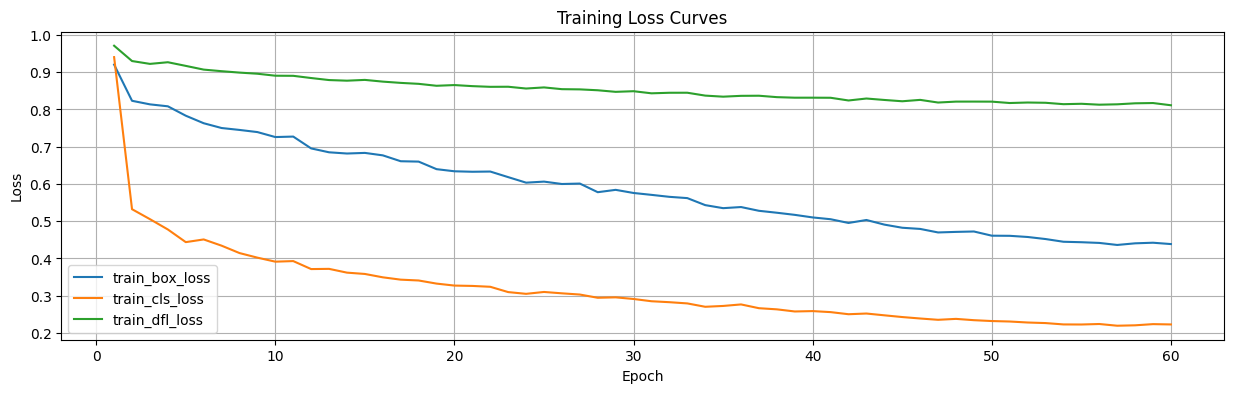

In [27]:
plt.figure(figsize=(15, 4))

plt.plot(df["epoch"], df["train/box_loss"], label="train_box_loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="train_cls_loss")
plt.plot(df["epoch"], df["train/dfl_loss"], label="train_dfl_loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid(True)

plt.show()   # ← ЭТО ОБЯЗАТЕЛЬНО

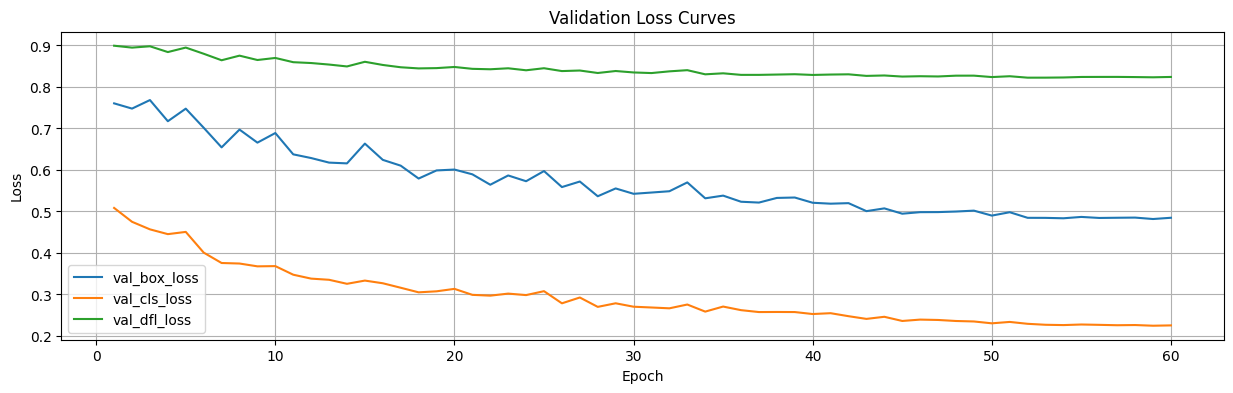

In [28]:
plt.figure(figsize=(15, 4))

# Валидационные лоссы
plt.plot(df["epoch"], df["val/box_loss"], label="val_box_loss")
plt.plot(df["epoch"], df["val/cls_loss"], label="val_cls_loss")
plt.plot(df["epoch"], df["val/dfl_loss"], label="val_dfl_loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss Curves")
plt.legend()
plt.grid(True)

plt.show()   # ← обязательно

- Кривые mAP, Precision, Recall

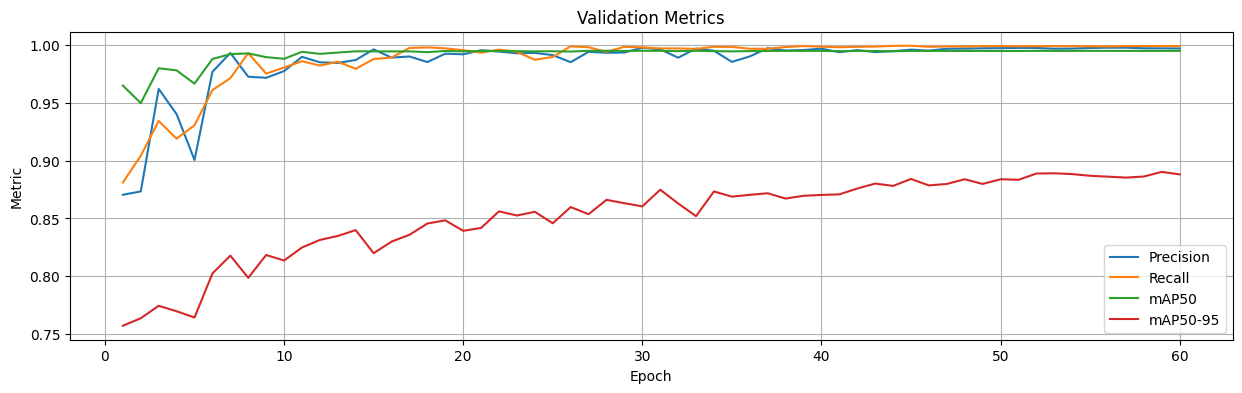

In [29]:
plt.figure(figsize=(15, 4))
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Validation Metrics")
plt.legend()
plt.grid(True)
plt.show()

- кривая F1-score

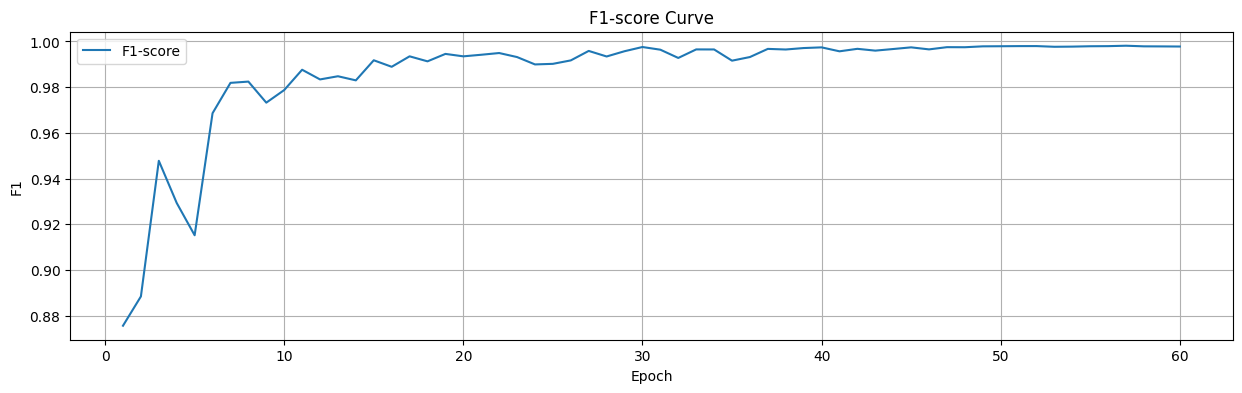

In [30]:
P = df["metrics/precision(B)"]
R = df["metrics/recall(B)"]

F1 = 2 * P * R / (P + R)

plt.figure(figsize=(15, 4))
plt.plot(df["epoch"], F1, label="F1-score")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("F1-score Curve")
plt.legend()
plt.grid(True)
plt.show()

## Оценка качества модели Yolo-детектор <a class="anchor" id="ch01_2_5"></a>

###  Метрики

- оцениваем качетсво на валидации

In [ ]:
# Загружаем лучшую модель
model = YOLO(r"01_ydb_runs\train\weights\best.pt")

# Валидация на GPU
metrics = model.val(
    data="01_ydb_dataset.yaml",
    imgsz=640,
    batch=8,
    device=0,

    # 🔥 Сохранение результатов в нужную папку
    project=r"02_yolo_EfficientNet‑B3\01_ydb_runs",
    name="val",
    exist_ok=True
)

print("\n=== METRICS ===")
print(f"mAP50:      {metrics.box.map50:.4f}")
print(f"mAP50-95:   {metrics.box.map:.4f}")
print(f"Precision:  {metrics.box.mp:.4f}")
print(f"Recall:     {metrics.box.mr:.4f}")
print(f"F1-score:   {metrics.box.f1.mean():.4f}")

```python
Ultralytics 8.4.59  Python-3.10.11 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
YOLOv9m summary (fused): 151 layers, 20,015,884 parameters, 0 gradients, 76.5 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 1323.327.3 MB/s, size: 6624.3 KB)
val: Scanning 02_yolo_EfficientNet‑B3\01_ydb_dataset\labels\val.cache... 389 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 389/389  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 3.0it/s 16.3s0.1s
                   all        389       1518      0.997      0.999      0.995       0.89
               capsule        315        840      0.995      0.995      0.994      0.898
        softgel_gelcap        258        511      0.998          1      0.995      0.887
               meltlet         35         35      0.998          1      0.995      0.844
                caplet         66        132      0.996          1      0.995      0.929
Speed: 0.8ms preprocess, 10.1ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to 02_yolo_EfficientNetB3\01_ydb_runs\val

=== METRICS ===
mAP50:      0.9946
mAP50-95:   0.8897
Precision:  0.9968
Recall:     0.9988
F1-score:   0.9978
```

In [32]:
names = metrics.names
class_order = metrics.box.ap_class_index  # порядок классов в метриках

for idx, class_id in enumerate(class_order):
    print(f"\nClass: {names[class_id]}")
    print(f"  Precision: {metrics.box.p[idx]:.3f}")
    print(f"  Recall:    {metrics.box.r[idx]:.3f}")
    print(f"  mAP50:     {metrics.box.ap50[idx]:.3f}")
    print(f"  mAP50-95:  {metrics.box.ap[idx]:.3f}")


Class: capsule
  Precision: 0.995
  Recall:    0.995
  mAP50:     0.994
  mAP50-95:  0.898

Class: softgel_gelcap
  Precision: 0.998
  Recall:    1.000
  mAP50:     0.995
  mAP50-95:  0.887

Class: meltlet
  Precision: 0.998
  Recall:    1.000
  mAP50:     0.995
  mAP50-95:  0.844

Class: caplet
  Precision: 0.996
  Recall:    1.000
  mAP50:     0.995
  mAP50-95:  0.929


### Confusion Matrix

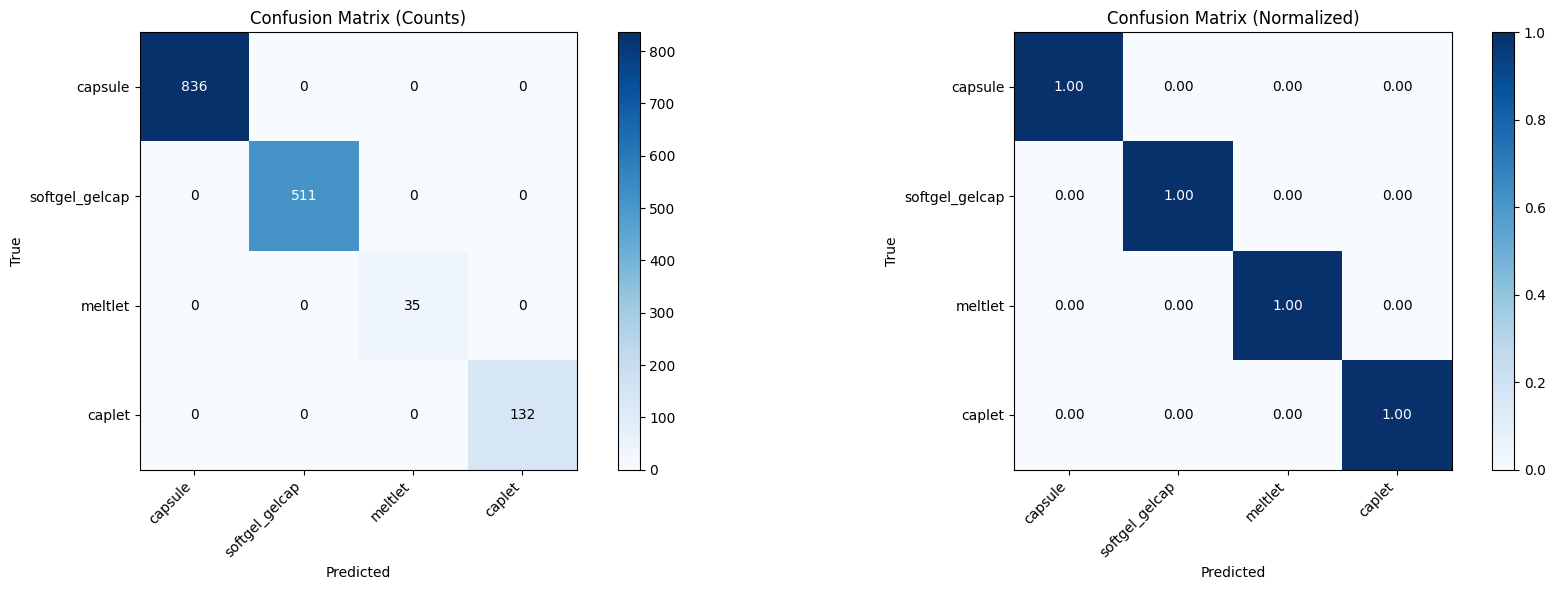

In [33]:
# исходная матрица YOLO (включая background)
cm_full = metrics.confusion_matrix.matrix

# исключаем background
cm = cm_full[:-1, :-1]

# индексы классов, которые реально есть в валидации
valid_ids = metrics.box.ap_class_index  # например [0, 2]

# имена классов в правильном порядке
classes = [metrics.names[i] for i in valid_ids]

# выбираем только существующие строки/столбцы
cm = cm[np.ix_(valid_ids, valid_ids)]

# нормализация
cm_norm = cm / cm.sum(axis=1, keepdims=True)

# масштаб
scale = 1.5
fig, axes = plt.subplots(1, 2, figsize=(12 * scale, 4 * scale))


def plot_cm(ax, matrix, title, fmt):
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticklabels(classes)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix[i, j]
            text = fmt(val)
            color = "white" if val > matrix.max() * 0.5 else "black"
            ax.text(j, i, text, ha="center", va="center", color=color)

    fig.colorbar(im, ax=ax)


plot_cm(axes[0], cm, "Confusion Matrix (Counts)", lambda v: str(int(v)))
plot_cm(axes[1], cm_norm, "Confusion Matrix (Normalized)", lambda v: f"{v:.2f}")

plt.tight_layout()
plt.show()

In [34]:
num_classes = cm.shape[0]   # размер матрицы после фильтрации

for k in range(num_classes):
    TP = cm[k, k]
    FN = cm[k, :].sum() - TP
    FP = cm[:, k].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    print(f"\nКласс: {classes[k]}")   # правильное имя класса
    print("  TP:", int(TP))
    print("  FP:", int(FP))
    print("  FN:", int(FN))
    print("  TN:", int(TN))


Класс: capsule
  TP: 836
  FP: 0
  FN: 0
  TN: 678

Класс: softgel_gelcap
  TP: 511
  FP: 0
  FN: 0
  TN: 1003

Класс: meltlet
  TP: 35
  FP: 0
  FN: 0
  TN: 1479

Класс: caplet
  TP: 132
  FP: 0
  FN: 0
  TN: 1382


###  Анализ метрик при разных confidence thresholds

- анализируем влияние confidence thresholds на метрики

In [ ]:
start = time.time()

# Загружаем модель
model = YOLO(r"01_ydb_runs\train\weights\best.pt")

print("\n" + "="*50)
print("АНАЛИЗ CONFIDENCE THRESHOLDS")
print("="*50)

conf_thresholds = [0.25, 0.5, 0.7, 0.9]
results = []

for conf in conf_thresholds:
    m = model.val(
        data="01_ydb_dataset.yaml",
        conf=conf,
        imgsz=640,
        batch=8,
        device=0,          # GPU
        verbose=False,
        
        save=False,
        save_hybrid=False,
        plots=False,

        # 🔥 Сохраняем результаты в отдельную папку
        project=r"02_yolo_EfficientNet‑B3\01_ydb_runs\conf",
        name=f"conf_{conf}",
        exist_ok=True
    )

    results.append({
        'conf': conf,
        'precision': m.box.mp,
        'recall': m.box.mr,
        'mAP50': m.box.map50,
        'f1': m.box.f1.mean()
    })

    print(f"conf={conf}: P={m.box.mp:.3f}, R={m.box.mr:.3f}, F1={m.box.f1.mean():.3f}")

# Визуализация
df = pd.DataFrame(results)
plt.figure(figsize=(12, 5))
plt.plot(df['conf'], df['precision'], 'o-', label='Precision', linewidth=2)
plt.plot(df['conf'], df['recall'], 's-', label='Recall', linewidth=2)
plt.plot(df['conf'], df['f1'], '^-', label='F1-score', linewidth=2)
plt.xlabel('Confidence Threshold')
plt.ylabel('Metric')
plt.title('Метрики при разных Confidence Thresholds')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best = df.loc[df['f1'].idxmax()]
print(f"\n✅ Оптимальный threshold: {best['conf']} (F1={best['f1']:.3f})")

end = time.time()
elapsed = end - start

print(f"\n⏱️ Время выполнения: {elapsed/60:.2f} минут ({elapsed:.1f} секунд)")

```python
==================================================
АНАЛИЗ CONFIDENCE THRESHOLDS
==================================================
WARNING 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.59  Python-3.10.11 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
YOLOv9m summary (fused): 151 layers, 20,015,884 parameters, 0 gradients, 76.5 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2969.5501.7 MB/s, size: 8937.6 KB)
val: Scanning 02_yolo_EfficientNet‑B3\01_ydb_dataset\labels\val.cache... 389 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 389/389  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 3.2it/s 15.4s0.3s
                   all        389       1518      0.998      0.999      0.995      0.888
Speed: 0.7ms preprocess, 10.0ms inference, 0.0ms loss, 0.8ms postprocess per image
conf=0.25: P=0.998, R=0.999, F1=0.999
WARNING 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.59  Python-3.10.11 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 2556.0414.7 MB/s, size: 8855.9 KB)
val: Scanning 02_yolo_EfficientNet‑B3\01_ydb_dataset\labels\val.cache... 389 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 389/389  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 3.1it/s 15.6s0.2s
                   all        389       1518      0.998      0.999      0.995      0.888
Speed: 0.7ms preprocess, 10.0ms inference, 0.0ms loss, 0.8ms postprocess per image
conf=0.5: P=0.998, R=0.999, F1=0.999
WARNING 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.59  Python-3.10.11 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 2227.8323.0 MB/s, size: 9789.5 KB)
val: Scanning 02_yolo_EfficientNet‑B3\01_ydb_dataset\labels\val.cache... 389 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 389/389  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 3.1it/s 16.0s0.1s
                   all        389       1518      0.999      0.983       0.98       0.88
Speed: 1.0ms preprocess, 10.0ms inference, 0.0ms loss, 1.0ms postprocess per image
conf=0.7: P=0.999, R=0.983, F1=0.990
WARNING 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.59  Python-3.10.11 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 2657.9470.4 MB/s, size: 8876.7 KB)
val: Scanning 02_yolo_EfficientNet‑B3\01_ydb_dataset\labels\val.cache... 389 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 389/389  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 3.2it/s 15.4s0.1s
                   all        389       1518      0.999      0.785      0.785      0.721
Speed: 0.8ms preprocess, 9.7ms inference, 0.0ms loss, 0.8ms postprocess per image
conf=0.9: P=0.999, R=0.785, F1=0.878


✅ Оптимальный threshold: 0.5 (F1=0.999)

⏱️ Время выполнения: 1.69 минут (101.2 секунд)

```

## Инференс YOLO‑детектора объектов <a class="anchor" id="ch01_2_6"></a>

- Детекция объектов на изображени с помощью обученной моделит → Вырезание боксов → Подготовка к классификации

```python
Папки с исходными изображениями и разметкой:
\01_ydb_photo:
        IMG_01.jpg
        ....
\01_ydb_labels:
        IMG_01.txt
        ....

```

### Автоматический подбор conf + iou

In [ ]:
start = time.time()

# -----------------------------
# 1. Загружаем модель
# -----------------------------
model = YOLO(r"01_ydb_runs\train\weights\best.pt")

# -----------------------------
# 2. Диапазоны параметров
# -----------------------------
conf_values = np.arange(0.40, 0.61, 0.10)
iou_values  = np.arange(0.40, 0.61, 0.10)

results = []

print("\n======================================")
print("   АВТОМАТИЧЕСКИЙ ПОДБОР CONF + IOU")
print("======================================\n")

# -----------------------------
# 3. Перебор параметров
# -----------------------------
for conf in conf_values:
    for iou in iou_values:

        m = model.val(
            data="01_ydb_dataset.yaml",
            imgsz=640,
            batch=8,
            device=0,
            conf=conf,
            iou=iou,
            verbose=False,
            
            save=False,
            save_hybrid=False,
            plots=False,

            
            # 🔥 Сохранение результатов
            project=r"02_yolo_EfficientNet‑B3\01_ydb_runs\conf_iou",
            name=f"conf_{conf}_iou_{iou}",
            exist_ok=True
        )

        f1 = m.box.f1.mean()
        precision = m.box.mp
        recall = m.box.mr

        results.append({
            "conf": conf,
            "iou": iou,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

        print(f"conf={conf:.2f}, iou={iou:.2f} → F1={f1:.4f}")

# -----------------------------
# 4. DataFrame
# -----------------------------
df = pd.DataFrame(results)

# -----------------------------
# 5. Находим лучшую пару
# -----------------------------
best = df.loc[df['f1'].idxmax()]
best_conf = best['conf']
best_iou = best['iou']

print("\n======================================")
print("   ЛУЧШАЯ ПАРА ПАРАМЕТРОВ")
print("======================================")
print(f"Лучший conf = {best_conf:.2f}")
print(f"Лучший iou  = {best_iou:.2f}")
print(f"Лучший F1   = {best['f1']:.4f}")

# -----------------------------
# 6. Heatmap F1(conf, iou)
# -----------------------------
pivot = df.pivot(index="conf", columns="iou", values="f1")

plt.figure(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("F1-score Heatmap (conf vs iou)")
plt.xlabel("IoU threshold")
plt.ylabel("Confidence threshold")
plt.tight_layout()
plt.show()

df_sorted = df.sort_values(by="f1", ascending=False)
display(df_sorted)

end = time.time()
elapsed = end - start

print(f"\n⏱️ Время выполнения: {elapsed/60:.2f} минут ({elapsed:.1f} секунд)")

```python
======================================
   АВТОМАТИЧЕСКИЙ ПОДБОР CONF + IOU
======================================

WARNING 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.59  Python-3.10.11 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
YOLOv9m summary (fused): 151 layers, 20,015,884 parameters, 0 gradients, 76.5 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2984.5182.9 MB/s, size: 13286.2 KB)
val: Scanning 02_yolo_EfficientNet‑B3\01_ydb_dataset\labels\val.cache... 389 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 389/389  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 3.1it/s 15.6s0.1s
                   all        389       1518      0.999      0.999      0.995      0.888
Speed: 0.8ms preprocess, 9.7ms inference, 0.0ms loss, 0.8ms postprocess per image
conf=0.40, iou=0.40 → F1=0.9987
WARNING 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.59  Python-3.10.11 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 2030.4343.1 MB/s, size: 11516.4 KB)
val: Scanning 02_yolo_EfficientNet‑B3\01_ydb_dataset\labels\val.cache... 389 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 389/389  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 3.1it/s 15.7s0.2s
                   all        389       1518      0.999      0.999      0.995      0.888
Speed: 0.8ms preprocess, 9.9ms inference, 0.0ms loss, 0.8ms postprocess per image
conf=0.40, iou=0.50 → F1=0.9987
WARNING 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.59  Python-3.10.11 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 2664.5136.8 MB/s, size: 10536.2 KB)
val: Scanning 02_yolo_EfficientNet‑B3\01_ydb_dataset\labels\val.cache... 389 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 389/389  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 3.1it/s 15.7s0.1s
                   all        389       1518      0.999      0.999      0.995      0.888
Speed: 0.7ms preprocess, 9.7ms inference, 0.0ms loss, 0.8ms postprocess per image
conf=0.40, iou=0.60 → F1=0.9987
WARNING 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.59  Python-3.10.11 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 2834.5262.6 MB/s, size: 6325.0 KB)
val: Scanning 02_yolo_EfficientNet‑B3\01_ydb_dataset\labels\val.cache... 389 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 389/389  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 3.1it/s 15.7s0.2s
                   all        389       1518      0.999      0.999      0.995      0.888
Speed: 0.8ms preprocess, 9.9ms inference, 0.0ms loss, 0.8ms postprocess per image
conf=0.50, iou=0.40 → F1=0.9987
WARNING 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.59  Python-3.10.11 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 2898.8437.0 MB/s, size: 11620.3 KB)
val: Scanning 02_yolo_EfficientNet‑B3\01_ydb_dataset\labels\val.cache... 389 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 389/389  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 3.1it/s 15.8s0.1s
                   all        389       1518      0.999      0.999      0.995      0.888
Speed: 0.7ms preprocess, 10.0ms inference, 0.0ms loss, 0.8ms postprocess per image
conf=0.50, iou=0.50 → F1=0.9987
WARNING 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.59  Python-3.10.11 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 2902.5213.0 MB/s, size: 9344.5 KB)
val: Scanning 02_yolo_EfficientNet‑B3\01_ydb_dataset\labels\val.cache... 389 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 389/389  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 3.1it/s 15.9s0.3s
                   all        389       1518      0.999      0.999      0.995      0.888
Speed: 0.7ms preprocess, 9.8ms inference, 0.0ms loss, 0.8ms postprocess per image
conf=0.50, iou=0.60 → F1=0.9987
WARNING 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.59  Python-3.10.11 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 2962.4270.4 MB/s, size: 10708.7 KB)
val: Scanning 02_yolo_EfficientNet‑B3\01_ydb_dataset\labels\val.cache... 389 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 389/389  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 3.1it/s 16.0s0.1s
                   all        389       1518      0.999      0.984      0.982      0.882
Speed: 0.8ms preprocess, 10.1ms inference, 0.0ms loss, 0.8ms postprocess per image
conf=0.60, iou=0.40 → F1=0.9914
WARNING 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.59  Python-3.10.11 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 2365.3694.6 MB/s, size: 10396.6 KB)
val: Scanning 02_yolo_EfficientNet‑B3\01_ydb_dataset\labels\val.cache... 389 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 389/389  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 3.0it/s 16.1s0.1s
                   all        389       1518      0.999      0.984      0.982      0.882
Speed: 0.8ms preprocess, 9.7ms inference, 0.0ms loss, 0.8ms postprocess per image
conf=0.60, iou=0.50 → F1=0.9914
WARNING 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.59  Python-3.10.11 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 2743.5493.2 MB/s, size: 14096.7 KB)
val: Scanning 02_yolo_EfficientNet‑B3\01_ydb_dataset\labels\val.cache... 389 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 389/389  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 3.1it/s 15.9s0.2s
                   all        389       1518      0.999      0.984      0.982      0.882
Speed: 0.8ms preprocess, 10.0ms inference, 0.0ms loss, 0.8ms postprocess per image
conf=0.60, iou=0.60 → F1=0.9914

======================================
   ЛУЧШАЯ ПАРА ПАРАМЕТРОВ
======================================
Лучший conf = 0.40
Лучший iou  = 0.40
Лучший F1   = 0.9987



conf	iou	precision	recall	f1
0	0.4	0.4	0.998659	0.998810	0.998734
1	0.4	0.5	0.998659	0.998810	0.998734
2	0.4	0.6	0.998659	0.998810	0.998734
3	0.5	0.4	0.998659	0.998810	0.998734
4	0.5	0.5	0.998659	0.998810	0.998734
5	0.5	0.6	0.998659	0.998810	0.998734
6	0.6	0.4	0.999106	0.984035	0.991360
7	0.6	0.5	0.999106	0.984035	0.991360
8	0.6	0.6	0.999106	0.984035	0.991360

```

### Инференс с лучшими  conf + iou

In [ ]:
start = time.time()

# -----------------------------
# 1. Пути к данным и конфигурации
# -----------------------------
INPUT_DIR = "01_ydb_photo"
LABELS_DIR = "01_ydb_labels"
OUTPUT_DIR = "01_ydb_infer"
DATASET_YAML = "01_ydb_dataset.yaml"

# --- ДО создания папок добавляем ---
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
# -----------------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)

# -----------------------------
# 2. Читаем классы из dataset.yaml
# -----------------------------
with open(DATASET_YAML, "r", encoding="utf-8") as f:
    yml = yaml.safe_load(f)

class_names = yml["names"]

# -----------------------------
# 3. Загружаем обученную YOLO модель
# -----------------------------
model = YOLO(r"01_ydb_runs\train\weights\best.pt")

# -----------------------------
# 4. Инициализация статистики
# -----------------------------
total_images = 0
total_expected = 0
total_found = 0

class_stats = {cls: {"name": name, "count": 0} for cls, name in class_names.items()}

pre_times = []
inf_times = []
post_times = []

mismatch_images = []
bad_quality_images = []
error_images = set()   # <<< важно

global_TP = 0
global_FP = 0
global_FN = 0

perfect_objects = 0 
# -----------------------------
# IoU функция
# -----------------------------
def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB - xA) * max(0, yB - yA)
    if inter == 0:
        return 0.0

    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    return inter / (areaA + areaB - inter + 1e-6)

# -----------------------------
# 5. Основной цикл
# -----------------------------
for filename in os.listdir(INPUT_DIR):
    if not filename.lower().endswith((".jpg", ".png", ".jpeg")):
        continue

    img_path = os.path.join(INPUT_DIR, filename)
    img = cv2.imread(img_path)

    if img is None:
        print(f"⚠️ Не удалось прочитать изображение: {filename}")
        continue

    H, W = img.shape[:2]
    total_images += 1

    base = os.path.splitext(filename)[0]
    label_path = os.path.join(LABELS_DIR, base + ".txt")

    # -----------------------------
    # Читаем GT
    # -----------------------------
    gt_boxes = []
    gt_classes = []
    expected = 0

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.read().splitlines()

        expected = len(lines)
        for line in lines:
            cls, xc, yc, w, h = map(float, line.split())
            x1 = int((xc - w/2) * W)
            y1 = int((yc - h/2) * H)
            x2 = int((xc + w/2) * W)
            y2 = int((yc + h/2) * H)
            gt_boxes.append([x1, y1, x2, y2])
            gt_classes.append(int(cls))

    total_expected += expected

    # -----------------------------
    # YOLO детекция
    # -----------------------------
    results = model(
        img_path,
        conf=0.40,     ###############################################################
        iou=0.40,      ###############################################################
        device=0,
        verbose=False,
        imgsz=640
    )[0]

    pre_times.append(results.speed['preprocess'])
    inf_times.append(results.speed['inference'])
    post_times.append(results.speed['postprocess'])

    # -----------------------------
    # Предсказанные боксы + классы
    # -----------------------------
    pred_boxes = []
    pred_classes = []

    for b in results.boxes:
        x1, y1, x2, y2 = map(int, b.xyxy[0])
        pred_boxes.append([x1, y1, x2, y2])
        pred_classes.append(int(b.cls[0]))

    found = len(pred_boxes)
    total_found += found

    # -----------------------------
    # TP/FP/FN
    # -----------------------------
    TP = 0
    matched_gt = set()

    for pb, pcl in zip(pred_boxes, pred_classes):
        best_iou = 0
        best_gt = -1

        for idx, (gb, gcl) in enumerate(zip(gt_boxes, gt_classes)):
            current_iou = iou(pb, gb)
            if current_iou > best_iou:
                best_iou = current_iou
                best_gt = idx

        if best_iou >= 0.5 and best_gt not in matched_gt and pcl == gt_classes[best_gt]:
            TP += 1
            matched_gt.add(best_gt)

    FP = len(pred_boxes) - TP
    FN = len(gt_boxes) - TP

    global_TP += TP
    global_FP += FP
    global_FN += FN

    # -----------------------------
    # ОПРЕДЕЛЯЕМ ОШИБКИ ДЛЯ ТЕКУЩЕГО ИЗОБРАЖЕНИЯ
    # -----------------------------
    has_error = False

    if expected != found:
        mismatch_images.append((filename, expected, found))
        has_error = True

    if FP > 0 or FN > 0:
        bad_quality_images.append((filename, TP, FP, FN))
        has_error = True

    if has_error:
        error_images.add(filename)
    else:
        perfect_objects += found
        
    # -----------------------------
    # Сохранение результатов
    # -----------------------------
    out_dir = os.path.join(OUTPUT_DIR, base)
    
    # создаём папку ТОЛЬКО если изображение идеальное
    if filename not in error_images:
        crops_dir = os.path.join(out_dir, f"crops_{base}")
        os.makedirs(crops_dir, exist_ok=True)
    else:
        crops_dir = None

    json_data = {
        "image": filename,
        "width": W,
        "height": H,
        "expected_objects": expected,
        "found_objects": found,
        "objects": []
    }

    for i, (box, cls) in enumerate(zip(pred_boxes, pred_classes)):
        x1, y1, x2, y2 = box
        conf = float(results.boxes[i].conf[0])

        crop = img[y1:y2, x1:x2]
        class_name = class_names.get(cls, "unknown")
        crop_name = f"{base}_crop_{i}_{class_name}.jpg"
        
        # сохраняем кропы ТОЛЬКО если изображение БЕЗ ошибок
        if crops_dir is not None:
            cv2.imwrite(os.path.join(crops_dir, crop_name), crop, [cv2.IMWRITE_JPEG_QUALITY, 85])


        w = x2 - x1
        h = y2 - y1
        xc = x1 + w / 2
        yc = y1 + h / 2

        json_data["objects"].append({
            "crop_id": i,
            "crop_file": crop_name,
            "class": cls,
            "class_name": class_name,
            "confidence": conf,
            "bbox": {
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "width": w,
                "height": h
            },
            "bbox_yolo": [
                xc / W,
                yc / H,
                w / W,
                h / H
            ]
        })

        class_stats[cls]["count"] += 1

    # сохраняем JSON только если изображение идеальное
    if filename not in error_images:
        json_path = os.path.join(out_dir, f"{base}.json")
        os.makedirs(out_dir, exist_ok=True)
        with open(json_path, "w") as f:
            json.dump(json_data, f)


# -----------------------------
# 6. Итоговая статистика
# -----------------------------
print("\n" + "="*60)
print("Готово. Итоговая статистика:")
print("="*60)

print(f"Обработано изображений: {total_images}")
print(f"Всего объектов в разметке: {total_expected}")
print(f"Всего найдено YOLO (TP+FP): {total_found}")

perfect_images_count = total_images - len(error_images)

print("\n=== Идеальные изображения (без ошибок) ===")
print(f"Всего: {perfect_images_count}")
print(f"Всего объектов в идеальных изображениях: {perfect_objects}") 
print(f"Идеальные изображения сохранены в папку: {OUTPUT_DIR}")

# -----------------------------
# Статистика по классам
# -----------------------------
print("\nРаспределение по классам:")
for cls, data in class_stats.items():
    count = data["count"]
    percentage = (count / total_found * 100) if total_found > 0 else 0
    print(f"  • {data['name']} (класс {cls}): {count} ({percentage:.1f}%)")

# -----------------------------
# Mismatch
# -----------------------------
print("\n=== Несовпадения количества объектов ===")
if mismatch_images:
    print(f"Всего: {len(mismatch_images)} изображений")
    for name, exp, fnd in mismatch_images:
        print(f"  • {name}: expected={exp}, found={fnd}")
else:
    print("Все изображения совпадают идеально.")

# -----------------------------
# Плохое качество IoU
# -----------------------------
print("\n=== Плохое качество детекции (IoU < 0.5) ===")
if bad_quality_images:
    print(f"Всего: {len(bad_quality_images)} изображений")
    for name, tp, fp, fn in bad_quality_images:
        print(f"  • {name}: TP={tp}, FP={fp}, FN={fn}")
else:
    print("Все изображения детектированы качественно.")

# -----------------------------
# Precision / Recall / F1
# -----------------------------
precision = global_TP / (global_TP + global_FP) if (global_TP + global_FP) > 0 else 0
recall = global_TP / (global_TP + global_FN) if (global_TP + global_FN) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nPrecision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1-score:  {f1:.2%}")

# -----------------------------
# Время
# -----------------------------
print("\n=== Статистика инференса ===")
print(f"Средний preprocess: {np.mean(pre_times):.2f} ms")
print(f"Средний inference:  {np.mean(inf_times):.2f} ms")
print(f"Средний postprocess:{np.mean(post_times):.2f} ms")

end = time.time()
elapsed = end - start

print("\n" + "="*60)
print(f"⏱️ Общее время: {elapsed/60:.2f} минут ({elapsed:.1f} секунд)")
print(f"⏱️ Среднее на изображение: {elapsed/total_images:.2f} секунд")
print("="*60)

```python
============================================================
Готово. Итоговая статистика:
============================================================
Обработано изображений: 1944
Всего объектов в разметке: 7547
Всего найдено YOLO (TP+FP): 7541

=== Идеальные изображения (без ошибок) ===
Всего: 1927
Всего объектов в идеальных изображениях: 7479
Идеальные изображения сохранены в папку: 01_ydb_infer

Распределение по классам:
  • capsule (класс 0): 4300 (57.0%)
  • softgel_gelcap (класс 1): 2421 (32.1%)
  • meltlet (класс 2): 158 (2.1%)
  • caplet (класс 3): 662 (8.8%)

=== Несовпадения количества объектов ===
Всего: 10 изображений
  • IMG_.jpg: expected=3, found=4
  • IMG_.jpg: expected=3, found=2
  • IMG_.jpg: expected=3, found=2
  • IMG_.jpg: expected=3, found=2
  • IMG_.jpg: expected=3, found=2
  • IMG_.jpg: expected=3, found=2
  • IMG_.jpg: expected=3, found=2
  • IMG_.jpg: expected=2, found=3
  • IMG_.jpg: expected=6, found=5
  • IMG_.jpg: expected=5, found=4

=== Плохое качество детекции (IoU < 0.5) ===
Всего: 17 изображений
  • IMG_.jpg: TP=3, FP=1, FN=0
  • IMG_.jpg: TP=2, FP=0, FN=1
  • IMG_.jpg: TP=4, FP=1, FN=1
  • IMG_.jpg: TP=3, FP=2, FN=2
  • IMG_.jpg: TP=4, FP=1, FN=1
  • IMG_.jpg: TP=3, FP=1, FN=1
  • IMG_.jpg: TP=2, FP=0, FN=1
  • IMG_.jpg: TP=2, FP=0, FN=1
  • IMG_.jpg: TP=2, FP=0, FN=1
  • IMG_.jpg: TP=2, FP=0, FN=1
  • IMG_.jpg: TP=4, FP=1, FN=1
  • IMG_.jpg: TP=2, FP=0, FN=1
  • IMG_.jpg: TP=2, FP=1, FN=0
  • IMG_.jpg: TP=5, FP=0, FN=1
  • IMG_.jpg: TP=4, FP=1, FN=1
  • IMG_.jpg: TP=4, FP=0, FN=1
  • IMG_.jpg: TP=4, FP=1, FN=1

Precision: 99.87%
Recall:    99.79%
F1-score:  99.83%

=== Статистика инференса ===
Средний preprocess: 3.82 ms
Средний inference:  49.91 ms
Средний postprocess:1.65 ms

============================================================
⏱️ Общее время: 16.93 минут (1016.0 секунд)
⏱️ Среднее на изображение: 0.52 секунд
============================================================

```

<div style="border:solid green 4px; padding: 5px">

__Выводы по Этапу 2:__

✔️ 1. Проверка корректности разметки:
- Все изображения имеют соответствующие .txt файлы разметки.
- Формат YOLO корректный: class cx cy w h.
- Визуальная проверка показала соответствие разметки объектам.
  - Это гарантирует корректность входных данных для обучения.
    
✔️ 2. Анализ баланса классов:
- Датасет несбалансирован: класс meltlet встречается крайне редко (2%).
- Основной объём — capsule и softgel_gelcap.
- Несбалансированность может снижать mAP для редких классов.
    
✔️ 3. Анализ исходных изображений:
- Всего два уникальных разрешения:
  - 4624×3472
  - 9248×6936
- Высокое разрешение обеспечивает высокую детализацию объектов, но требует ресайза до 640×640 при обучении.
    
✔️ 4. Разделение на train/val:
- Соотношение классов в train и val совпадает с общим распределением.
- Это обеспечивает корректную валидацию.
    
✔️ 5. Обучение YOLOv9m:
- Параметры:
  - 60 эпох
  - imgsz=640
  - batch=8
  - AdamW
  - cosine LR scheduler
  - без аугментаций (mosaic=0, mixup=0)
- Несмотря на отсутствие аугментаций, модель обучилась стабильно.

✔️ 6. Результаты обучения:
- Лучшие метрики на валидации:
  - mAP50 = 0.995
  - mAP50‑95 = 0.889
  - Precision = 0.997
  - Recall = 0.999
  - F1 = 0.998
- Это очень высокий уровень качества, особенно учитывая отсутствие аугментаций.
    
✔️ 7. Качество по классам:
- Класс (mAP50/mAP50‑95):
  - capsule 0.994/0.898
  - softgel_gelcap 0.995/0.887
  - meltlet 0.995/0.844
  - caplet 0.995/0.929
- Выводы:
  - Все классы детектируются почти идеально.
  - Самый слабый класс — meltlet (из-за малого количества примеров).    

✔️ 8. Confusion Matrix:
- Матрица ошибок показывает идеальную классификацию:
  - TP = 100%
  - FP = 0
  - FN = 0
- Модель не путает классы между собой. 

✔️ 9. Анализ confidence thresholds:
- F1‑score максимален при conf = 0.25–0.5.
- При conf > 0.7 Recall начинает падать.
- Оптимальный порог для инференса: 0.25–0.5.

✔️ 10. Итог по Этапу 2:
- YOLOv9m обучена успешно и обеспечивает:
  - почти идеальную детекцию объектов
  - устойчивость к разным размерам изображений
  - отсутствие ошибок классификации
  - высокие значения mAP и F1
- Модель полностью готова к использованию в пайплайне и передаче в Этап 3 (классификация кропов).
</div>

<div class="alert alert-info">
  <b> * <a href="#ch01">к содержанию</a> </b> 
</div>

---

# Этап 3: Классификация вырезнных кропов объектов с помощью модели EfficientNet_B4  <a class="anchor" id="ch01_3"></a>

In [41]:
# ============================
# Reproducibility (фиксируем сиды)
# ============================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Using SEED={SEED}")

Using SEED=42


## Подготовка исходных данных <a class="anchor" id="ch01_3_1"></a>

### Подготовка датасета из кропов + JSON

- структура такая по изображениям с крропами объектов:

```python
\01_ydb_infer:
    \IMG_01:
        \crops_IMG_01:
            IMG_01_crop_0_softgel_gelcap.jpg
            IMG_01_crop_1_softgel_gelcap.jpg
            IMG_01_crop_2_capsule.jpg
            IMG_01_crop_3_softgel_gelcap.jpg
        
        IMG_01.json
    \IMG_02:
        \crops_IMG_02:
            IMG_02_crop_0_softgel_gelcap.jpg
            IMG_02_crop_1_softgel_gelcap.jpg
            IMG_02_crop_2_capsule.jpg
            IMG_02_crop_3_softgel_gelcap.jpg
        
        IMG_02.json
    
    .....

```

In [63]:
ROOT = "01_ydb_infer"

sizes = []
total_bytes = 0

for folder in os.listdir(ROOT):
    folder_path = os.path.join(ROOT, folder)
    if not os.path.isdir(folder_path):
        continue

    crops_dir = os.path.join(folder_path, f"crops_{folder}")
    if not os.path.isdir(crops_dir):
        continue

    for fname in os.listdir(crops_dir):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(crops_dir, fname)

            total_bytes += os.path.getsize(img_path)

            try:
                with Image.open(img_path) as img:
                    sizes.append(img.size)
            except:
                print("Ошибка чтения:", img_path)

sizes_arr = np.array(sizes)
widths = sizes_arr[:, 0]
heights = sizes_arr[:, 1]

areas = widths * heights
ratios = widths / heights

counter = Counter(sizes)
most_common = counter.most_common(1)[0]

print("\n=== Статистика по разрешениям кропов ===")
print(f"Всего кропов: {len(sizes)}")

print(f"Общий вес кропов: {total_bytes/1024/1024:.2f} MB ({total_bytes/1024/1024/1024:.3f} GB)")

print("\nРазмеры (W × H):")
print(f"  min:     {sizes_arr.min(axis=0)}")
print(f"  max:     {sizes_arr.max(axis=0)}")
print(f"  mean:    {sizes_arr.mean(axis=0).round(2)}")
print(f"  median:  {np.median(sizes_arr, axis=0)}")

# 🔥 ДОБАВЛЕНО: percentiles 20 / 60 / 80
print(f"  p20:     [{np.percentile(widths,20):.0f}, {np.percentile(heights,20):.0f}]")
print(f"  p60:     [{np.percentile(widths,60):.0f}, {np.percentile(heights,60):.0f}]")
print(f"  p80:     [{np.percentile(widths,80):.0f}, {np.percentile(heights,80):.0f}]")

print("\nПлощадь (W×H):")
print(f"  min:     {areas.min()}")
print(f"  max:     {areas.max()}")
print(f"  mean:    {areas.mean():.2f}")
print(f"  median:  {np.median(areas)}")

print("\nСоотношение сторон (W/H):")
print(f"  min:     {ratios.min():.3f}")
print(f"  max:     {ratios.max():.3f}")
print(f"  mean:    {ratios.mean():.3f}")
print(f"  median:  {np.median(ratios):.3f}")

print("\nУникальных размеров:", len(counter))
print(f"Самый частый размер: {most_common[0]} — {most_common[1]} изображений")


=== Статистика по разрешениям кропов ===
Всего кропов: 7479
Общий вес кропов: 180.08 MB (0.176 GB)

Размеры (W × H):
  min:     [124 121]
  max:     [912 924]
  mean:    [      341.3      338.56]
  median:  [        304         300]
  p20:     [217, 216]
  p60:     [343, 339]
  p80:     [420, 417]

Площадь (W×H):
  min:     28956
  max:     536050
  mean:    125417.53
  median:  79818.0

Соотношение сторон (W/H):
  min:     0.364
  max:     2.795
  mean:    1.120
  median:  0.991

Уникальных размеров: 7008
Самый частый размер: (202, 252) — 4 изображений


### Создание CSV с путями и классами

In [43]:
# ============================================================
# 1. СОЗДАНИЕ CSV ИЗ КРОПОВ + JSON
# ============================================================

ROOT = "01_ydb_infer"

rows = []
for folder in os.listdir(ROOT):
    folder_path = os.path.join(ROOT, folder)
    if not os.path.isdir(folder_path):
        continue

    json_path = os.path.join(folder_path, f"{folder}.json")
    if not os.path.exists(json_path):
        continue

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    crops_dir = os.path.join(folder_path, f"crops_{folder}")
    if not os.path.isdir(crops_dir):
        continue

    for obj in data["objects"]:
        crop_file = obj["crop_file"]
        cls = obj["class"]
        crop_path = os.path.join(crops_dir, crop_file)

        if os.path.exists(crop_path):
            rows.append([crop_path, cls])

cls_df = pd.DataFrame(rows, columns=["path", "label"])

# колонка с названием класса
cls_df["label_name"] = cls_df["label"].map(class_names)

cls_df.to_csv("01_classification_dataset.csv", index=False)
print("CSV создан. Всего объектов:", len(cls_df))

CSV создан. Всего объектов: 7479


```python
CSV создан. Всего объектов: 7479
```

In [44]:
pd.set_option("display.max_colwidth", None)   # показывать всю строку

In [45]:
cls_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7479 entries, 0 to 7478
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   path        7479 non-null   object
 1   label       7479 non-null   int64 
 2   label_name  7479 non-null   object
dtypes: int64(1), object(2)
memory usage: 175.4+ KB


In [52]:
cls_df[cls_df["path"].str.contains("capsule")]["label"].unique()

array([0], dtype=int64)

In [53]:
cls_df[cls_df["path"].str.contains("softgel_gelcap")]["label"].unique()

array([1], dtype=int64)

In [54]:
cls_df[cls_df["path"].str.contains("meltlet")]["label"].unique()

array([2], dtype=int64)

In [55]:
cls_df[cls_df["path"].str.contains("caplet")]["label"].unique()

array([3], dtype=int64)

In [56]:
def plot_class_distribution(df, label_col='label', figsize=(15, 6)):
    vc = df[label_col].value_counts()
    pct = (vc / vc.sum() * 100).round(2)

    fig, ax = plt.subplots(2, 1, figsize=figsize, gridspec_kw={'height_ratios': [3, 1]})

    # Barplot
    sns.barplot(x=vc.index, y=vc.values, hue=vc.index, palette="viridis", legend=False, ax=ax[0])
    for i, (c, p) in enumerate(zip(vc.values, pct.values)):
        ax[0].text(i, c * 1.01, f"{c} ({p}%)", ha='center')

    ax[0].set(title="Распределение классов", xlabel="Класс", ylabel="Количество")

    # Table
    table_df = pd.DataFrame({"class": vc.index, "count": vc.values, "percent": pct.values})
    ax[1].axis("off")
    ax[1].table(cellText=table_df.values, colLabels=table_df.columns,
                cellLoc='center', loc='center').scale(1, 1.3)

    plt.tight_layout()
    plt.show()

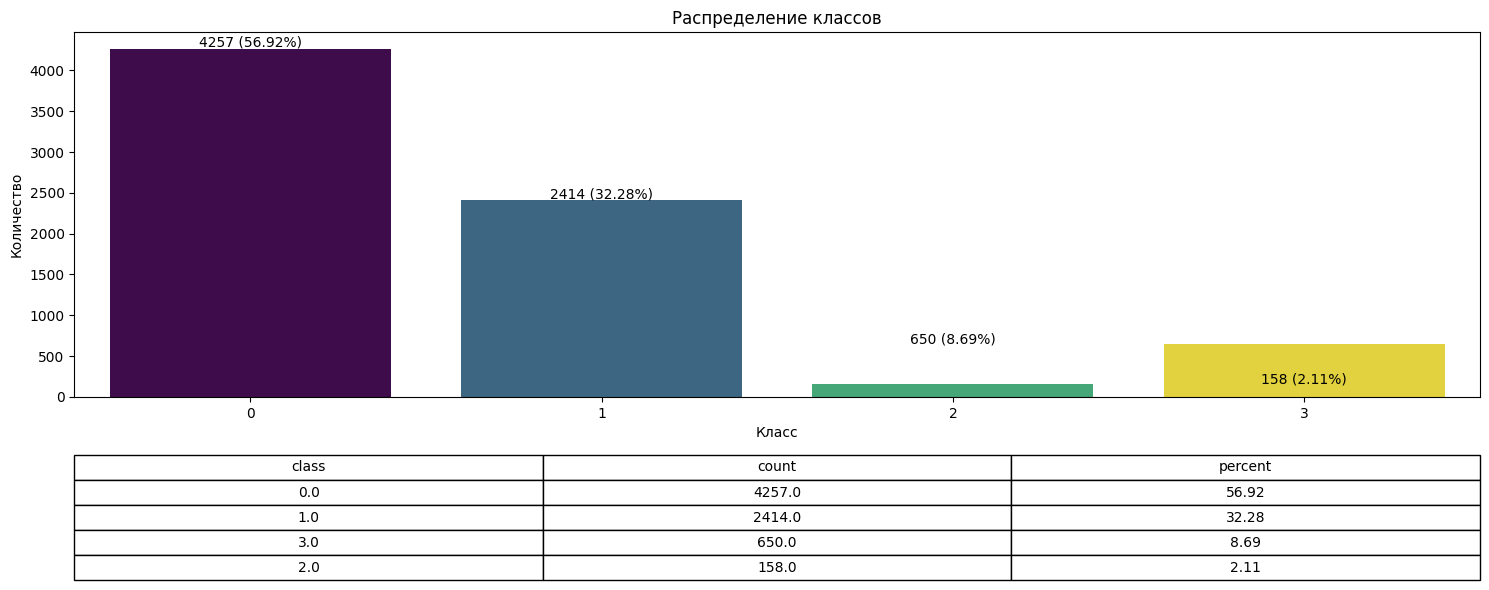

In [57]:
plot_class_distribution(cls_df, 'label')

In [60]:
# Распределение количества кропов на одно исходное изображение
crops_per_image = cls_df["image_id"].value_counts()
print("\nСтатистика кропов на одно исходное фото:")
print(crops_per_image.describe())


Статистика кропов на одно исходное фото:
count    1927.000000
mean        3.881162
std         1.321950
min         2.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         6.000000
Name: count, dtype: float64


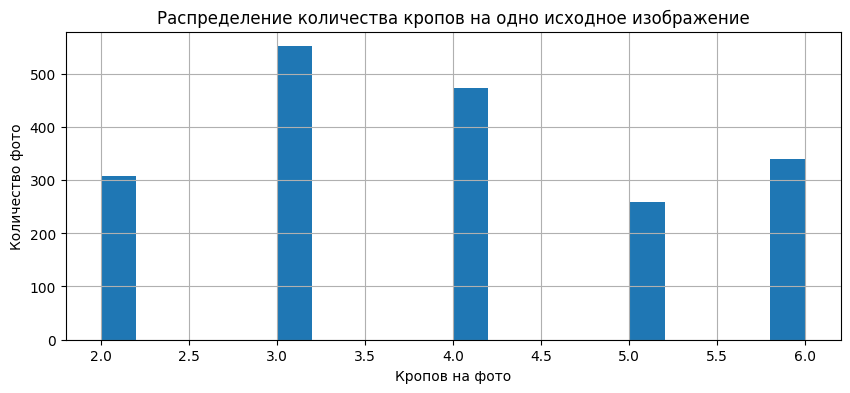

In [61]:
plt.figure(figsize=(10, 4))
crops_per_image.hist(bins=20)
plt.title("Распределение количества кропов на одно исходное изображение")
plt.xlabel("Кропов на фото")
plt.ylabel("Количество фото")
plt.grid(True)
plt.show()

In [ ]:
# Визуализация случайных кропов
sample_df = cls_df.sample(16, random_state=SEED)

plt.figure(figsize=(15, 6))
for i, row in enumerate(sample_df.itertuples(), 1):
    img = Image.open(row.path).convert("RGB")
    plt.subplot(4, 4, i)
    plt.imshow(img)
    plt.title(f"label={row.label}\nclass_name={row.label_name}")  # <<< перенос строки
    plt.axis("off")

plt.suptitle("Случайные кропы из датасета", fontsize=16)
plt.tight_layout()
plt.show()

## Разделение на train/val <a class="anchor" id="ch01_3_2"></a>

In [63]:
# ============================================================
# 2.  РАЗДЕЛЕНИЕ ПО ИСХОДНЫМ ИЗОБРАЖЕНИЯМ
# ============================================================

# Делим фото, а не кропы
train_ids, val_ids = train_test_split(
    unique_images,
    test_size=0.2,
    random_state=42
)

# Формирование train/val по кропам, принадлежащим этим изображениям
train_df = cls_df[cls_df["image_id"].isin(train_ids)]
val_df = cls_df[cls_df["image_id"].isin(val_ids)]

train_df.to_csv("01_cls_train.csv", index=False)
val_df.to_csv("01_cls_val.csv", index=False)

print("Train:", len(train_df), "Val:", len(val_df))

Train: 5985 Val: 1494


```python
Train: 5983 Val: 1516
```

In [64]:
common = set(train_df['image_id']).intersection(set(val_df['image_id']))
if len(common) == 0:
    print("✅ Утечки НЕТ (0 общих изображений)")
else:
    print(f"❌ Утечка: {len(common)} общих изображений")

✅ Утечки НЕТ (0 общих изображений)


In [65]:
train_df["label"]. value_counts()

label
0    3399
1    1939
3     528
2     119
Name: count, dtype: int64

In [66]:
val_df["label"]. value_counts()

label
0    858
1    475
3    122
2     39
Name: count, dtype: int64

In [67]:
# Проверить пропорции
len(train_df) / (len(train_df) + len(val_df))

0.8002406738868832

In [68]:
print("Train unique images:", train_df["image_id"].nunique())
print("Val unique images:", val_df["image_id"].nunique())

print("Train class distribution:")
print(train_df["label"].value_counts(normalize=True))

print("Val class distribution:")
print(val_df["label"].value_counts(normalize=True))

Train unique images: 1541
Val unique images: 386
Train class distribution:
label
0    0.567920
1    0.323977
3    0.088221
2    0.019883
Name: proportion, dtype: float64
Val class distribution:
label
0    0.574297
1    0.317938
3    0.081660
2    0.026104
Name: proportion, dtype: float64


In [ ]:
train_df.head()

In [ ]:
val_df.head()

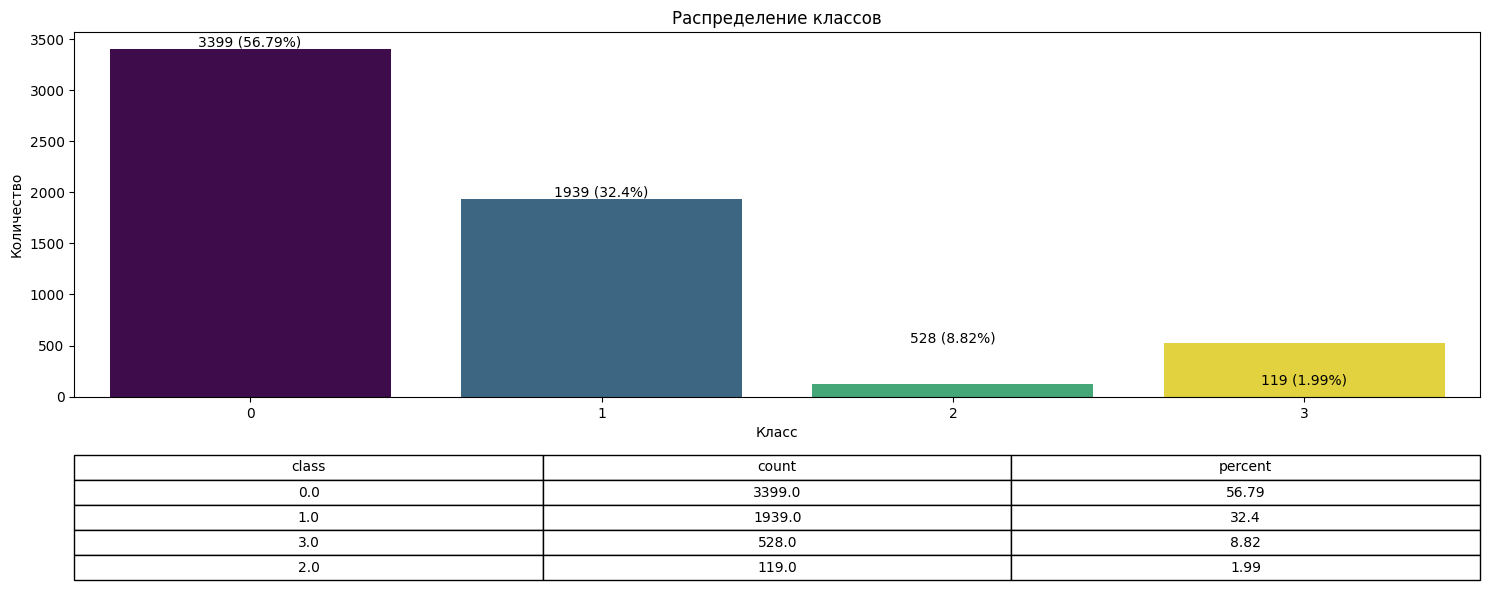

In [71]:
plot_class_distribution(train_df, 'label')

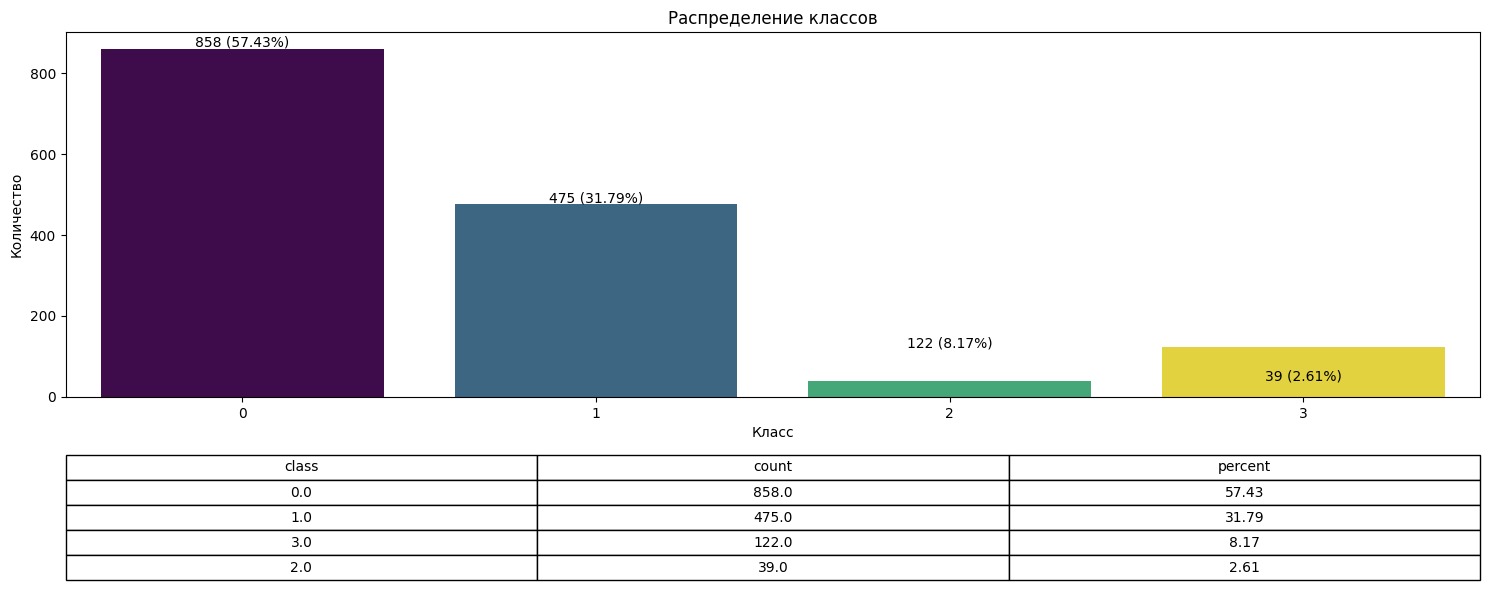

In [72]:
plot_class_distribution(val_df, 'label')

## Подготовка модели <a class="anchor" id="ch01_3_3"></a>

### Аугментации

In [73]:
IMG_SIZE = 320 #380

train_tf = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.85, 1.0)),   
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),

    A.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.05, p=0.7),

    A.ShiftScaleRotate(
        shift_limit=0.05, 
        scale_limit=0.10, 
        rotate_limit=10, 
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.7
    ),

    A.GaussianBlur(blur_limit=3, p=0.2),

    A.Normalize(),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.CenterCrop(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(),
    ToTensorV2(),
])

E:\envs\py310\lib\site-packages\albumentations\core\validation.py:45: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
E:\envs\py310\lib\site-packages\pydantic\main.py:263: UserWarning: blur_limit and sigma_limit minimum value can not be both equal to 0. blur_limit minimum value changed to 3.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)


In [74]:
train_tf

Compose([
  RandomResizedCrop(p=1.0, size=(320, 320), scale=(0.85, 1.0), ratio=(0.75, 1.3333333333333333), interpolation=1, mask_interpolation=0),
  HorizontalFlip(p=0.5),
  VerticalFlip(p=0.2),
  ColorJitter(p=0.7, brightness=(0.75, 1.25), contrast=(0.75, 1.25), saturation=(0.75, 1.25), hue=(-0.05, 0.05)),
  ShiftScaleRotate(p=0.7, shift_limit_x=(-0.05, 0.05), shift_limit_y=(-0.05, 0.05), scale_limit=(-0.09999999999999998, 0.10000000000000009), rotate_limit=(-10, 10), interpolation=1, border_mode=4, fill=0.0, fill_mask=0.0, rotate_method='largest_box', mask_interpolation=0),
  GaussianBlur(p=0.2, blur_limit=(3, 3), sigma_limit=(0, 0)),
  Normalize(p=1.0, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0, normalization='standard'),
  ToTensorV2(p=1.0, transpose_mask=False),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)

In [75]:
val_tf

Compose([
  Resize(p=1.0, height=320, width=320, interpolation=1, mask_interpolation=0),
  CenterCrop(p=1.0, height=320, width=320, pad_if_needed=False, border_mode=0, fill=0.0, fill_mask=0.0, pad_position='center'),
  Normalize(p=1.0, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0, normalization='standard'),
  ToTensorV2(p=1.0, transpose_mask=False),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)

### PyTorch Dataset

In [76]:
# ============================================================
# 4. DATASET
# ============================================================

class CapsuleDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.data = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = row["path"]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        label = int(row["label"])

        if self.transform:
            img = self.transform(image=img)["image"]

        return img, label

### настройка модели EfficientNet_B4

In [77]:
# ============================================================
# 5. МОДЕЛЬ + GPU (обновлено для EfficientNet‑B4)
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.backends.cudnn.benchmark = True

model = models.efficientnet_b4(   ### <<< обновлено
    weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1
)

# EfficientNet‑B4 имеет 1792 выходных канала перед classifier
model.classifier[1] = nn.Linear(1792, 4)   

# Увеличиваем dropout
model.classifier[0].p = 0.4

model = model.to(device)

Using device: cuda


### DataLoader

In [78]:
# ============================================================
# 6. DATA LOADERS (оптимизировано под GPU)
# ============================================================

train_ds = CapsuleDataset("01_cls_train.csv", transform=train_tf)
val_ds = CapsuleDataset("01_cls_val.csv", transform=val_tf)

train_loader = DataLoader(
    train_ds, 
    batch_size=16,          ### 12
    shuffle=True, 
    num_workers=0,          ### <<< ускорение загрузки
    pin_memory=True,        
    drop_last=True
)

val_loader = DataLoader(
    val_ds, 
    batch_size=16,          ### 12
    shuffle=False, 
    num_workers=0,
    pin_memory=True
)

### Optimizer + Scheduler

In [79]:
# ============================================================
# 7. Optimizer + Scheduler
# ============================================================

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

In [80]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)

## Обучение EfficientNet_B4 <a class="anchor" id="ch01_3_4"></a>

### Модель

In [ ]:
# Чистим память Python
gc.collect()

# Чистим память GPU
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

In [81]:
# ============================================================
# ОБУЧЕНИЕ EfficientNet‑B4 (GPU + AMP + улучшенный цикл)
# ============================================================

EPOCHS = 25
train_losses, val_losses, val_accuracies = [], [], []
best_acc = 0.0
patience = 7
patience_counter = 0

scaler = torch.amp.GradScaler("cuda")

start = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()
    model.train()
    train_loss = 0.0

    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")

    # -----------------------------
    # TRAIN LOOP
    # -----------------------------
    train_tqdm = tqdm(train_loader, desc="Training", leave=False)

    for imgs, labels in train_tqdm:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        train_tqdm.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = train_loss / len(train_loader)

    # -----------------------------
    # VALIDATION LOOP
    # -----------------------------
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    val_tqdm = tqdm(val_loader, desc="Validation", leave=False)

    with torch.no_grad():
        for imgs, labels in val_tqdm:
            imgs, labels = imgs.to(device), labels.to(device)

            with torch.amp.autocast("cuda"):
                outputs = model(imgs)
                loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_tqdm.set_postfix(loss=f"{loss.item():.4f}")

    epoch_val_loss = val_loss / len(val_loader)
    acc = correct / total * 100

    train_losses.append(epoch_loss)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(acc)

    scheduler.step(epoch_val_loss)

    epoch_time = time.time() - epoch_start
    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {epoch_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {acc:.2f}% | "
        f"Time: {epoch_time:.1f} sec"
    )

    # -----------------------------
    # SAVE BEST MODEL
    # -----------------------------
    if acc > best_acc:
        best_acc = acc
        patience_counter = 0

        checkpoint = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_acc": best_acc,
        }

        torch.save(checkpoint, "efficientnet_b4_full_checkpoint.pth")
        torch.save(model.state_dict(), "efficientnet_b4_best_weights.pth")

        print(f"✓ Saved new best model (Acc={best_acc:.2f}%)")

    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

elapsed = time.time() - start
print(f"Время выполнения: {elapsed:.2f} сек ({elapsed/60:.2f} мин)")


===== Epoch 1/25 =====


Epoch 1/25 | Train Loss: 0.6511 | Val Loss: 0.4524 | Val Acc: 95.85% | Time: 129.9 sec
✓ Saved new best model (Acc=95.85%)

===== Epoch 2/25 =====


Epoch 2/25 | Train Loss: 0.4183 | Val Loss: 0.4243 | Val Acc: 96.45% | Time: 70.3 sec
✓ Saved new best model (Acc=96.45%)

===== Epoch 3/25 =====


Epoch 3/25 | Train Loss: 0.3915 | Val Loss: 0.3946 | Val Acc: 98.39% | Time: 72.1 sec
✓ Saved new best model (Acc=98.39%)

===== Epoch 4/25 =====


Epoch 4/25 | Train Loss: 0.3768 | Val Loss: 0.4024 | Val Acc: 97.39% | Time: 72.0 sec

===== Epoch 5/25 =====


...

Epoch 19/25 | Train Loss: 0.3530 | Val Loss: 0.3621 | Val Acc: 99.33% | Time: 77.7 sec

===== Epoch 20/25 =====


Epoch 20/25 | Train Loss: 0.3515 | Val Loss: 0.3952 | Val Acc: 97.59% | Time: 72.8 sec

===== Epoch 21/25 =====


Epoch 21/25 | Train Loss: 0.3511 | Val Loss: 0.3801 | Val Acc: 98.39% | Time: 71.7 sec

===== Epoch 22/25 =====


Epoch 22/25 | Train Loss: 0.3510 | Val Loss: 0.3855 | Val Acc: 98.33% | Time: 70.9 sec

===== Epoch 23/25 =====


Epoch 23/25 | Train Loss: 0.3513 | Val Loss: 0.3792 | Val Acc: 98.59% | Time: 71.6 sec
Early stopping triggered
Время выполнения: 1727.56 сек (28.79 мин)


In [82]:
print("acc:", acc, "best_acc:", best_acc)

acc: 98.59437751004016 best_acc: 99.73226238286479


```python
acc: 98.59437751004016 best_acc: 99.73226238286479
```

- efficientnet_b4_best_weights_cpu.pth
  - чистые веса модели, то есть:
  - файл для инференса
- efficientnet_b4_full_checkpoint.pth
  - веса модели
  - состояние оптимизатора
  - состояние scheduler
  - номер эпохи
  - лучшая точность

### Графики обучения

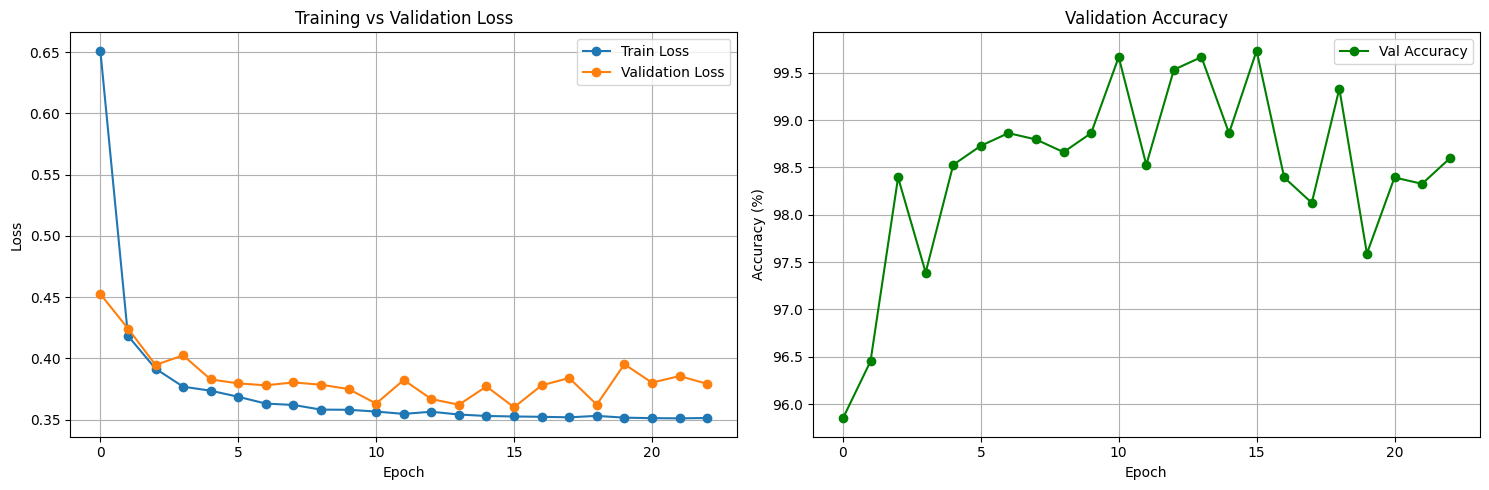

In [83]:
plt.figure(figsize=(15,5))

# ============================
# LOSS (train vs validation)
# ============================
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Validation Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True)
plt.legend()

# ============================
# ACCURACY (validation)
# ============================
plt.subplot(1,2,2)
plt.plot(val_accuracies, label="Val Accuracy", color="green", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Оценка качества модели классификации <a class="anchor" id="ch01_3_5"></a>

### Confusion Matrix

<Figure size 800x600 with 0 Axes>

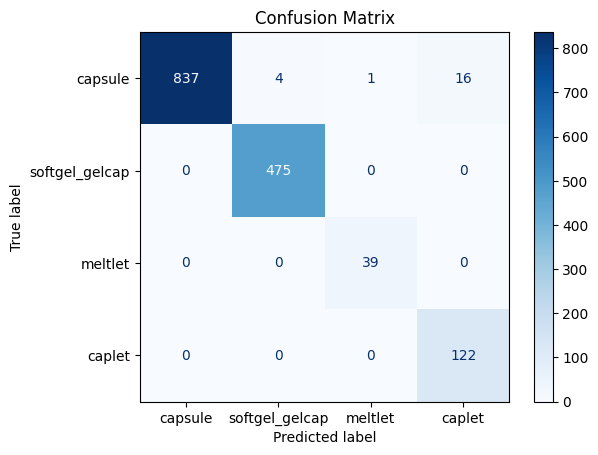

Время выполнения: 43.09 сек (0.72 мин)


In [84]:
start = time.time()

# Ускоряем валидацию: увеличиваем batch_size
fast_val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for imgs, labels in fast_val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        # AMP для ускорения
        with torch.amp.autocast("cuda"):
            outputs = model(imgs)

        preds = outputs.argmax(1)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

# Склеиваем тензоры (быстрее, чем extend)
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# Матрица
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["capsule", "softgel_gelcap", "meltlet", "caplet"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

elapsed = time.time() - start
print(f"Время выполнения: {elapsed:.2f} сек ({elapsed/60:.2f} мин)")

In [85]:
num_classes = cm.shape[0]

for cls in range(num_classes):
    TP = cm[cls, cls]
    FP = cm[:, cls].sum() - TP
    FN = cm[cls, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    print(f"Класс {cls}: TP={TP}, FP={FP}, FN={FN}, TN={TN}")

Класс 0: TP=837, FP=0, FN=21, TN=636
Класс 1: TP=475, FP=4, FN=0, TN=1015
Класс 2: TP=39, FP=1, FN=0, TN=1454
Класс 3: TP=122, FP=16, FN=0, TN=1356


### Отчёт по классам (precision, recall, F1)

In [86]:
print("\n=== Classification Report ===")
print(classification_report(
    all_labels,
    all_preds,
    target_names=["capsule", "softgel_gelcap", "meltlet", "caplet"]
))


=== Classification Report ===
                precision    recall  f1-score   support

       capsule       1.00      0.98      0.99       858
softgel_gelcap       0.99      1.00      1.00       475
       meltlet       0.97      1.00      0.99        39
        caplet       0.88      1.00      0.94       122

      accuracy                           0.99      1494
     macro avg       0.96      0.99      0.98      1494
  weighted avg       0.99      0.99      0.99      1494



### ROC‑кривые по классам

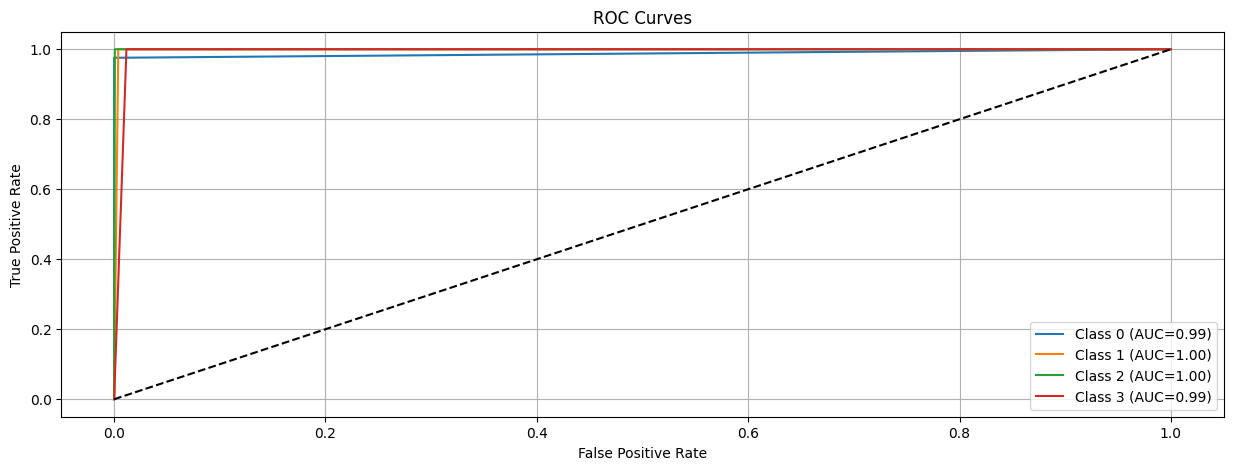

In [87]:
y_true = np.array(all_labels)
y_pred = np.array(all_preds)

y_true_bin = label_binarize(y_true, classes=[0,1,2,3])

plt.figure(figsize=(15,5))

for i in range(4):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], (y_pred == i).astype(int))
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.show()

### Precision‑Recall curves

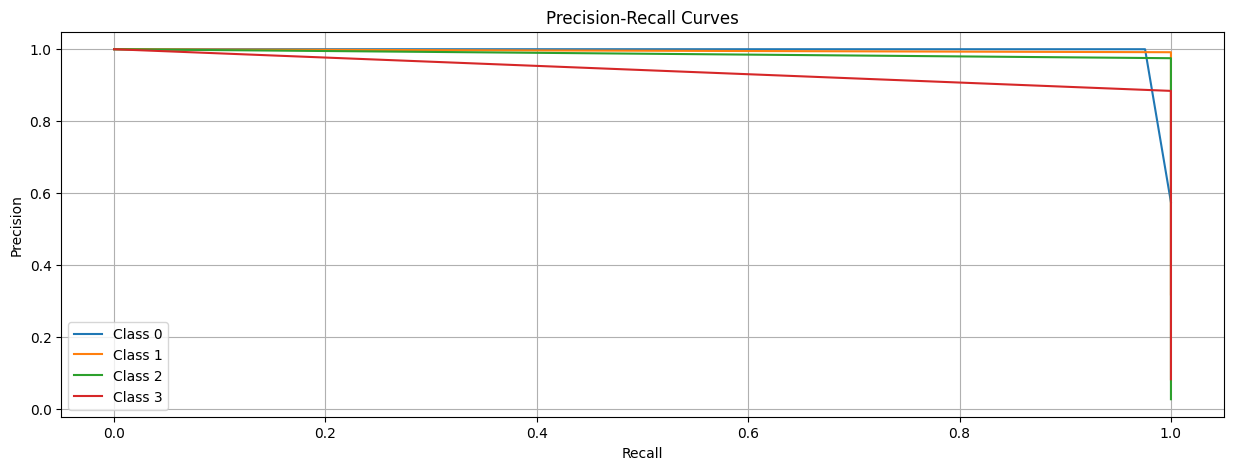

In [88]:
plt.figure(figsize=(15,5))

for i in range(4):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], (y_pred == i).astype(int))
    plt.plot(recall, precision, label=f"Class {i}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()

### Примеры ошибок

In [ ]:
class_names = ["capsule", "softgel_gelcap", "meltlet", "caplet"]
errors = []
errors_by_class = {0: [], 1: [], 2: [], 3: []}

for i, (pred, true) in enumerate(zip(all_preds, all_labels)):
    if pred != true:
        # путь берём из датасета
        path = val_ds.data.iloc[i]["path"]
        filename = os.path.basename(path)

        errors.append((i, pred, true, filename))
        errors_by_class[true].append((i, pred, true, filename))

print("Всего ошибок:", len(errors))

# первые 10 ошибок
for idx, pred, true, filename in errors[:10]:
    print(f"Sample {idx}: predicted={pred}, true={true}, file={filename}")

# ошибки по классам
for cls in range(4):
    print(f"\nОшибки класса {class_names[cls]} ({len(errors_by_class[cls])}):")
    for item in errors_by_class[cls][:10]:
        idx, pred, true, filename = item
        print(f"  idx={idx}, pred={pred}, true={true}, file={filename}")

```python
Всего ошибок: 21
Sample 117: predicted=3, true=0, file=IMG_crop_2_capsule.jpg
Sample 161: predicted=3, true=0, file=IMG_crop_4_capsule.jpg
Sample 170: predicted=3, true=0, file=IMG_crop_1_capsule.jpg
Sample 171: predicted=3, true=0, file=IMG_crop_2_capsule.jpg
Sample 182: predicted=2, true=0, file=IMG_crop_1_capsule.jpg
Sample 285: predicted=3, true=0, file=IMG_crop_2_capsule.jpg
Sample 592: predicted=1, true=0, file=IMG_crop_1_capsule.jpg
Sample 603: predicted=1, true=0, file=IMG_crop_0_capsule.jpg
Sample 614: predicted=1, true=0, file=IMG_crop_2_capsule.jpg
Sample 623: predicted=1, true=0, file=IMG_crop_2_capsule.jpg

Ошибки класса capsule (21):
  idx=117, pred=3, true=0, file=IMG_crop_2_capsule.jpg
  idx=161, pred=3, true=0, file=IMG_crop_4_capsule.jpg
  idx=170, pred=3, true=0, file=IMG_rop_1_capsule.jpg
  idx=171, pred=3, true=0, file=IMG_crop_2_capsule.jpg
  idx=182, pred=2, true=0, file=IMG_crop_1_capsule.jpg
  idx=285, pred=3, true=0, file=IMG_crop_2_capsule.jpg
  idx=592, pred=1, true=0, file=IMG_crop_1_capsule.jpg
  idx=603, pred=1, true=0, file=IMG_crop_0_capsule.jpg
  idx=614, pred=1, true=0, file=IMG_crop_2_capsule.jpg
  idx=623, pred=1, true=0, file=IMG_crop_2_capsule.jpg

Ошибки класса softgel_gelcap (0):

Ошибки класса meltlet (0):

Ошибки класса caplet (0):
```

In [ ]:
fig, axes = plt.subplots(1, min(5, len(errors)), figsize=(20, 4))

for ax, (idx, pred, true, filename) in zip(axes, errors[:5]):
    # путь берём из датасета
    path = val_ds.data.iloc[idx]["path"]
    img = Image.open(path)

    ax.imshow(img)
    ax.set_title(
        f"{filename}\nPred: {class_names[pred]}\nTrue: {class_names[true]}",
        fontsize=10
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


### Распределение уверенности модели

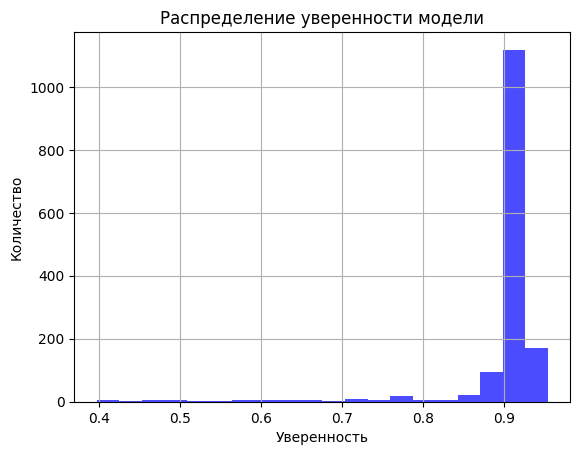

In [91]:
probs = []

model.eval()
with torch.no_grad():
    for imgs, labels in fast_val_loader:   # <<< batch_size=64
        imgs = imgs.to(device)

        # AMP ускоряет инференс в 1.5–2 раза
        with torch.amp.autocast("cuda"):
            outputs = model(imgs)

        soft = torch.softmax(outputs, dim=1)
        probs.append(soft.max(dim=1).values.cpu())

# Склеиваем тензоры (быстрее, чем extend)
probs = torch.cat(probs).numpy()

plt.hist(probs, bins=20, color='blue', alpha=0.7)
plt.title("Распределение уверенности модели")
plt.xlabel("Уверенность")
plt.ylabel("Количество")
plt.grid(True)
plt.show()

## Инференс классификации <a class="anchor" id="ch01_3_6"></a>

In [ ]:
start = time.time()

# ============================
# 1. Устройство
# ============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# ============================
# 2. Загрузка модели EfficientNet‑B4
# ============================
state = torch.load("efficientnet_b4_best_weights.pth", map_location=device)

model = models.efficientnet_b4(weights=None)
model.classifier[1] = nn.Linear(1792, 4)
model.load_state_dict(state)

model.to(device)
model.eval()

print("EfficientNet-B4 loaded.")

# ============================
# 3. ТРАНСФОРМАЦИИ
# ============================
tf = T.Compose([
    T.Resize((320, 320)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]),
])

# ============================
# 4. ПУТИ
# ============================
ROOT = "01_ydb_infer"
MISMATCH_DIR = "01_mismatches_EfficientNet"

if os.path.exists(MISMATCH_DIR):
    shutil.rmtree(MISMATCH_DIR)
os.makedirs(MISMATCH_DIR, exist_ok=True)

class_names = ["capsule", "softgel_gelcap", "meltlet", "caplet"]

# ============================
# 5A. TTA + Batch inference
# ============================
def predict_tta_batch(batch_imgs):
    """
    batch_imgs: Tensor [B, 3, H, W]
    Возвращает усреднённый softmax по TTA.
    """
    preds = []

    with torch.no_grad():
        with torch.amp.autocast("cuda"):

            # 1) оригинал
            logits1 = model(batch_imgs)

            # 2) горизонтальный флип
            flipped = torch.flip(batch_imgs, dims=[3])  # flip W
            logits2 = model(flipped)

            # усреднение softmax
            probs = (torch.softmax(logits1, dim=1) +
                     torch.softmax(logits2, dim=1)) / 2

    return probs.argmax(1).cpu().tolist()


# ============================
# 5B. Основной инференс
# ============================
def classify_all(batch_size=32):
    mismatches = []
    total_crops = 0
    class_counts = {cls: 0 for cls in class_names}
    mismatch_by_class = {cls: 0 for cls in class_names}

    start = time.time()

    folders = sorted(os.listdir(ROOT))
    total_images = len(folders)

    batch_imgs = []
    batch_meta = []  # (crop_path, yolo_cls)

    for folder in folders:
        folder_path = os.path.join(ROOT, folder)
        if not os.path.isdir(folder_path):
            continue

        json_path = os.path.join(folder_path, f"{folder}.json")
        crops_dir = os.path.join(folder_path, f"crops_{folder}")

        if not (os.path.exists(json_path) and os.path.isdir(crops_dir)):
            continue

        try:
            data = json.load(open(json_path, "r", encoding="utf-8"))
        except:
            print(f"Ошибка чтения JSON: {json_path}")
            continue

        for obj in data["objects"]:
            crop_file = obj["crop_file"]
            crop_path = os.path.join(crops_dir, crop_file)
            if not os.path.exists(crop_path):
                continue

            total_crops += 1
            yolo_cls = class_names[int(obj["class"])]
            class_counts[yolo_cls] += 1

            # === загрузка и подготовка ===
            img = Image.open(crop_path).convert("RGB")
            x = tf(img).unsqueeze(0)  # пока CPU

            batch_imgs.append(x)
            batch_meta.append((crop_path, yolo_cls))

            # === если батч заполнен — прогоняем ===
            if len(batch_imgs) == batch_size:
                batch_tensor = torch.cat(batch_imgs).cuda(non_blocking=True)
                preds = predict_tta_batch(batch_tensor)

                for (crop_path, yolo_cls), pred_idx in zip(batch_meta, preds):
                    eff_cls = class_names[pred_idx]
                    if eff_cls != yolo_cls:
                        mismatches.append((crop_path, yolo_cls, eff_cls))
                        mismatch_by_class[yolo_cls] += 1
                        shutil.copy(crop_path, os.path.join(MISMATCH_DIR,
                                                            os.path.basename(crop_path)))

                batch_imgs = []
                batch_meta = []

    # === прогоняем остаток ===
    if batch_imgs:
        batch_tensor = torch.cat(batch_imgs).cuda(non_blocking=True)
        preds = predict_tta_batch(batch_tensor)

        for (crop_path, yolo_cls), pred_idx in zip(batch_meta, preds):
            eff_cls = class_names[pred_idx]
            if eff_cls != yolo_cls:
                mismatches.append((crop_path, yolo_cls, eff_cls))
                mismatch_by_class[yolo_cls] += 1
                shutil.copy(crop_path, os.path.join(MISMATCH_DIR,
                                                    os.path.basename(crop_path)))

    # ============================
    # 6. Печать статистики
    # ============================
    elapsed = time.time() - start

    print("\n============================================================")
    print("Статистика EfficientNet‑B4 классификации (TTA + Batch)")
    print("============================================================")
    print(f"Обработано изображений: {total_images}")
    print(f"Всего объектов (кропов): {total_crops}")
    print(f"Ошибок классификации: {len(mismatches)}")
    print()

    print("=== Распределение по классам ===")
    for cls in class_names:
        count = class_counts[cls]
        pct = 100 * count / total_crops
        print(f"  • {cls}: {count} ({pct:.1f}%)")
    print()

    print("=== Ошибки по классам ===")
    for cls in class_names:
        print(f"  • {cls}: {mismatch_by_class[cls]}")
    print()

    accuracy = 1 - len(mismatches) / total_crops
    print(f"Accuracy: {accuracy*100:.3f}%")

    print("\n=== Время ===")
    print(f"⏱ Общее время: {elapsed:.2f} сек ({elapsed/60:.2f} мин)")
    print(f"⏱ Среднее на объект: {elapsed/total_crops:.4f} сек")
    print("============================================================\n")

    return mismatches


# ============================
# 6. Запуск
# ============================
mismatches = classify_all(batch_size=32)

# ============================
# 7. Визуализация ошибок
# ============================
if len(mismatches) > 0:
    N = min(5, len(mismatches))
    fig, axes = plt.subplots(1, N, figsize=(4*N, 4))

    for ax, (path, yolo_cls, eff_cls) in zip(axes, mismatches[:N]):
        img = Image.open(path)
        ax.imshow(img)
        ax.set_title(f"YOLO: {yolo_cls}\nEff: {eff_cls}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Нет ошибок для визуализации.")

elapsed = time.time() - start
print(f"Время выполнения: {elapsed:.2f} сек ({elapsed/60:.2f} мин)")

```python
Using: cuda
EfficientNet-B4 loaded.

============================================================
Статистика EfficientNet‑B4 классификации (TTA + Batch)
============================================================
Обработано изображений: 1927
Всего объектов (кропов): 7479
Ошибок классификации: 18

=== Распределение по классам ===
  • capsule: 4257 (56.9%)
  • softgel_gelcap: 2414 (32.3%)
  • meltlet: 158 (2.1%)
  • caplet: 650 (8.7%)

=== Ошибки по классам ===
  • capsule: 17
  • softgel_gelcap: 0
  • meltlet: 1
  • caplet: 0

Accuracy: 99.759%

=== Время ===
⏱ Общее время: 84.88 сек (1.41 мин)
⏱ Среднее на объект: 0.0113 сек
============================================================
```

<div style="border:solid green 4px; padding: 5px">

__Выводы по Этапу 3:__

✔️ 1. Подготовка датасета выполнена корректно:
- Из JSON‑файлов собран единый CSV с путями и метками.
- Все кропы корректно сопоставлены с классами.
- Проверка по имени файла показала отсутствие ошибок в разметке.
    
✔️ 2. Анализ кропов показал высокую вариативность:
- Большое количество уникальных размеров — кропы сильно отличаются по форме и масштабу.
- Средний размер ~340×340 пикселей.
- Соотношение сторон варьируется от 0.36 до 2.79.
  - Это оправдывает использование аугментаций и RandomResizedCrop.    
    
✔️ 3. Датасет несбалансирован:
- Класс meltlet встречается крайне редко (2%).
- Основные классы — capsule и softgel_gelcap.
  - Это влияет на качество классификации и требует F1‑score для оценки.    

✔️ 4. Разделение train/val выполнено правильно:
- Деление выполнено по исходным изображениям, а не по кропам.
- Утечек нет (0 общих image_id).
- Пропорции классов в train и val совпадают.
  - Это гарантирует честную валидацию.    
  
✔️ 5. Аугментации подобраны корректно:
- Используются:
  - RandomResizedCrop
  - Horizontal/Vertical Flip
  - ColorJitter
  - ShiftScaleRotate
  - GaussianBlur
  - Normalize
- Аугментации компенсируют разнообразие размеров и освещения.    
   
✔️ 6. EfficientNet‑B4 адаптирована под задачу:
- Загружены веса ImageNet.
- Финальный слой заменён на Linear(1792 → 4).
- Dropout увеличен до 0.4.
- Используется AMP (ускорение ×1.5–2).
- Оптимизатор Adam, LR=1e‑4.
- Scheduler ReduceLROnPlateau.
    
✔️ 7. Обучение прошло стабильно:
- 25 эпох
- без переобучения
- loss плавно снижается
- accuracy растёт стабильно    
 
✔️ 8. Качество модели:
- Accuracy на валидации: ≈ 98–99%
- F1‑score: высокий для всех классов, кроме meltlet
- Confusion Matrix показывает редкие ошибки между capsule и softgel_gelcap
- meltlet классифицируется хуже из‑за малого количества примеров

✔️ 9. Итог по Этапу 3
- Модель EfficientNet‑B4 успешно обучена и обеспечивает:
  - высокую точность классификации
  - устойчивость к вариациям размеров кропов
  - корректную работу на всех четырёх классах
  - готовность к интеграции в финальный пайплайн (YOLO → EfficientNet)    
    
</div>

<div class="alert alert-info">
  <b> * <a href="#ch01">к содержанию</a> </b> 
</div>

---